# **Final Project Kelompok 3**

Nama Anggota :
- Zafirah Aida Adista (Data Analyst)
- Muhammad Rafli Febriyanto (Data Analyst)
- Muhamad Imam Ferdiansyah (Data Engineer)

Batch : CODA-RMT-015

Program ini bertujuan untuk menganalisis efektivitas kampanye pemasaran digital serta melakukan *customer pruning* guna mengurangi prospek segmen customer dengan performa rendah. Hal ini dilakukan untuk mengoptimalisasi alokasi sumber daya pada target pelanggan potensial demi meningkatkan efisiensi strategi marketing dan pertumbuhan penjualan perusahaan.


**Kaggle** : https://www.kaggle.com/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset?utm

## Import Dataset

In [ ]:
# Import Libraries

# Data Acquisition & File Management
import kagglehub
import os
# Data Manipulation & Analysis
import pandas as pd
import numpy as np
# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [ ]:
# Download dataset dan inisialisasi path direktori file
path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")
files = os.listdir(path)
file_csv = os.path.join(path, files[0])

Using Colab cache for faster access to the 'predict-conversion-in-digital-marketing-dataset' dataset.


In [ ]:
# Membaca file CSV
df = pd.read_csv(file_csv)

# Menampilkan 5 data teratas
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


## Exploratory Data Analysis

In [ ]:
# Cek info kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [ ]:
# Cek statistik dasar kolom tipe numerik
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


**Insight:**


*   **Conversion**: Rata-rata konversi 0,87. Artinya 87% customer dalam dataset melakukan pembelian. Nilai std 0,32 cukup rendah, artinya performa konversi relatif stabil di seluruh dataset
*   **Age:** Rata-rata usia adalah 43 tahun dengan range 18–69 tahun.

*   **Income:** Rata-rata income 84,664 dengan median di 84,926. Artinya, distribusi pendapatan simetris dan berada di kelas menengah

*   **AdSpend**: Rata-rata pengeluaran per user adalah 5,000. Nilai Min (100) dan Max (9,997) menunjukkan tersebar merata dari budget kecil hingga besar

*  **Website Visits:** Rata-rata user berkunjung 24-25 kali. Artinya, user butuh berkali-kali datang sebelum konversi

*   **Pages Per Visit:** Rata-rata melihat 5-6 halaman per kunjungan. Menunjukkan indikator navigasi web yang baik

*   **Time On Site:** Rata-rata menghabiskan 7.7 menit. Ini angka yang sangat sehat untuk membangun kepercayaan pelanggan

*   **Previous Purchases:** Rata-rata sudah pernah beli 4-5 kali menunjukkan sebagian besar user adalah pelanggan lama yang loyal

*  **Loyalty Points:** Rata-rata poin mencapai 2490 dari nilai max 5000 mengindikasikan dominasi  pelanggan tetap, bukan one-time buyers









In [ ]:
# Cek unique values pada kolom kategorikal
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    print(df[col].value_counts())
    print("-" * 30)

Gender
Female    4839
Male      3161
Name: count, dtype: int64
------------------------------
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64
------------------------------
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64
------------------------------
AdvertisingPlatform
IsConfid    8000
Name: count, dtype: int64
------------------------------
AdvertisingTool
ToolConfid    8000
Name: count, dtype: int64
------------------------------


In [ ]:
# Cek missing values
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


Tidak terdapat missing values pada dataset

In [ ]:
# Cek duplicate values
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplicate values pada dataset

In [ ]:
# Campaign Channel Performance
df.groupby('CampaignChannel').agg(
    {
        'AdSpend' : 'median',
        'ConversionRate' : 'mean',
        'Conversion' : 'sum',
        'ClickThroughRate' : 'mean',
    }
).reset_index()

,CampaignChannel,AdSpend,ConversionRate,Conversion,ClickThroughRate
0,Email,5061.710188,0.104884,1355,0.155609
1,PPC,4909.581233,0.104132,1461,0.158307
2,Referral,5016.876899,0.103051,1518,0.151673
3,SEO,5062.784638,0.103530,1359,0.153150
4,Social Media,5036.734206,0.106550,1319,0.155523


In [ ]:
# Dataset Overview
print(f"""
Total Customers       : {len(df)}
Total Conversion      : {df['Conversion'].sum()}
Conversion Rate (%)   : {df['Conversion'].mean() * 100:.2f}%
Average Ad Spend      : {df['AdSpend'].mean():.2f}
""")


Total Customers       : 8000
Total Conversion      : 7012
Conversion Rate (%)   : 87.65%
Average Ad Spend      : 5000.94



## Transform Data

### 1.  Drop Kolom tidak relevan

In [ ]:
# Menghapus kolom AdvertisingPlatform dan AdvertisingTool
df = df.drop(['AdvertisingPlatform', 'AdvertisingTool'], axis=1)

### 2. Ubah Tipe Data

In [ ]:
# Mengubah tipe data kolom "PagesPerVisit" menjadi integer, kolom "CustomerID" menjadi string, kolom "Conversion" menjadi boolean
df = df.astype({'PagesPerVisit': 'int64','CustomerID': 'str'})

### 3. Ubah Nama kolom

In [ ]:
# Mengubah nama kolom "ConversionRate" menjadi "HistoryCR"
df.rename(columns={'ConversionRate': 'HistoryCR'}, inplace=True)

In [ ]:
# Memastikan kolom berhasil ditransform
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         8000 non-null   object 
 1   Age                8000 non-null   int64  
 2   Gender             8000 non-null   object 
 3   Income             8000 non-null   int64  
 4   CampaignChannel    8000 non-null   object 
 5   CampaignType       8000 non-null   object 
 6   AdSpend            8000 non-null   float64
 7   ClickThroughRate   8000 non-null   float64
 8   HistoryCR          8000 non-null   float64
 9   WebsiteVisits      8000 non-null   int64  
 10  PagesPerVisit      8000 non-null   int64  
 11  TimeOnSite         8000 non-null   float64
 12  SocialShares       8000 non-null   int64  
 13  EmailOpens         8000 non-null   int64  
 14  EmailClicks        8000 non-null   int64  
 15  PreviousPurchases  8000 non-null   int64  
 16  LoyaltyPoints      8000 

## Data Analysis

### 1. Segmen customer yang menghasilkan nilai % conversion rate yang tinggi ?

In [ ]:
# Melakukan partisi kolom numerikal menjadi 10 kelompok (Q1, Q2, ..... Q10)
col_bins = [
    'Age', 'Income', 'AdSpend', 'ClickThroughRate', 'HistoryCR',
    'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
    'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints'
]
df_bins = df.copy()

for col in col_bins:
  df_bins[f"{col}_range"] = pd.qcut(df_bins[col], q=10, duplicates='drop')
  # Contoh pembulatan 2 angka di belakang koma
  df_bins[f"{col}_range"] = df_bins[f"{col}_range"].apply(
      lambda x: f"{max(0,round(x.left, 2))} - {round(x.right, 2)}" if pd.notnull(x) else x
  )


df_bins


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,HistoryCR,WebsiteVisits,...,ClickThroughRate_range,HistoryCR_range,WebsiteVisits_range,PagesPerVisit_range,TimeOnSite_range,SocialShares_range,EmailOpens_range,EmailClicks_range,PreviousPurchases_range,LoyaltyPoints_range
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,...,0.04 - 0.07,0.08 - 0.1,0 - 5.0,1.0 - 2.0,6.21 - 7.68,10.0 - 20.0,4.0 - 6.0,8.0 - 9.0,3.0 - 4.0,523.9 - 1014.0
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,...,0.16 - 0.18,0.18 - 0.2,40.0 - 44.0,1.0 - 2.0,4.81 - 6.21,0 - 10.0,0 - 2.0,6.0 - 7.0,1.0 - 2.0,3444.0 - 3946.4
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,...,0.27 - 0.3,0.07 - 0.08,0 - 5.0,7.0 - 8.0,13.62 - 15.0,0 - 10.0,9.0 - 11.0,1.0 - 2.0,6.0 - 8.0,1997.0 - 2497.0
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,...,0.13 - 0.16,0.08 - 0.1,44.0 - 49.0,3.0 - 4.0,13.62 - 15.0,80.0 - 90.0,0 - 2.0,1.0 - 2.0,0 - 1.0,1997.0 - 2497.0
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,...,0.24 - 0.27,0.1 - 0.12,0 - 5.0,1.0 - 2.0,13.62 - 15.0,0 - 10.0,4.0 - 6.0,5.0 - 6.0,6.0 - 8.0,3946.4 - 4497.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,15995,21,Male,24849,Email,Awareness,8518.308575,0.243792,0.116773,23,...,0.24 - 0.27,0.1 - 0.12,20.0 - 25.0,8.0 - 9.0,13.62 - 15.0,60.0 - 70.0,11.0 - 13.0,5.0 - 6.0,6.0 - 8.0,0 - 523.9
7996,15996,43,Female,44718,SEO,Retention,1424.613446,0.236740,0.190061,49,...,0.21 - 0.24,0.18 - 0.2,44.0 - 49.0,8.0 - 9.0,3.35 - 4.81,50.0 - 60.0,11.0 - 13.0,0 - 1.0,4.0 - 5.0,1496.4 - 1997.0
7997,15997,28,Female,125471,Referral,Consideration,4609.534635,0.056526,0.133826,35,...,0.04 - 0.07,0.12 - 0.14,30.0 - 35.0,1.0 - 2.0,13.62 - 15.0,30.0 - 40.0,15.0 - 17.0,0 - 1.0,2.0 - 3.0,523.9 - 1014.0
7998,15998,19,Female,107862,PPC,Consideration,9476.106354,0.023961,0.138386,49,...,0.01 - 0.04,0.12 - 0.14,44.0 - 49.0,1.0 - 2.0,3.35 - 4.81,80.0 - 90.0,0 - 2.0,4.0 - 5.0,6.0 - 8.0,2497.0 - 2977.8


In [ ]:
# Melakukan grouping pada tiap column bins ke dalam dictionary untuk mengetahui conversion rate (%) tiap kategori
df_results = {}

for col in col_bins:
    temp = df_bins.groupby(f"{col}_range").agg(
        conversion_rate=('Conversion', 'mean')
    ).reset_index()

    temp['Conversion Rate (%)'] = temp['conversion_rate'] * 100

    df_results[col] = temp[[f"{col}_range", 'Conversion Rate (%)']]

/tmp/ipykernel_569/3248914757.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df_bins.groupby(f"{col}_range").agg(
/tmp/ipykernel_569/3248914757.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df_bins.groupby(f"{col}_range").agg(
/tmp/ipykernel_569/3248914757.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df_bins.groupby(f"{col}_range").agg(
/tmp/ipykernel_569/3248914757.py:5: FutureWarn

In [ ]:
# Menampilkan hasil grouping
df_results

{'Age':      Age_range  Conversion Rate (%)
 0  18.0 - 23.0            86.363636
 1  23.0 - 28.0            89.211618
 2  28.0 - 34.0            85.454545
 3  34.0 - 39.0            89.380531
 4  39.0 - 43.0            89.489489
 5  43.0 - 49.0            88.228823
 6  49.0 - 54.0            86.496815
 7  54.0 - 59.0            87.381275
 8  59.0 - 64.0            88.847118
 9  64.0 - 69.0            86.472149,
 'Income':           Income_range  Conversion Rate (%)
 0    20014.0 - 32436.0               86.625
 1    32436.0 - 45057.6               85.875
 2    45057.6 - 58900.0               88.375
 3    58900.0 - 71597.4               88.250
 4    71597.4 - 84926.5               87.625
 5    84926.5 - 98508.0               87.875
 6   98508.0 - 110503.8               87.375
 7  110503.8 - 123430.0               88.500
 8  123430.0 - 136216.2               87.375
 9  136216.2 - 149986.0               88.625,
 'AdSpend':        AdSpend_range  Conversion Rate (%)
 0   100.05 - 1103.08    

#### a. Berdasarkan Demografi (Age, Gender, Income)

In [ ]:
# Mengetahui nilai conversion rate berdasarkan gender customer
df_gender = df.groupby('Gender').agg(
    Total_Customer=('CustomerID', 'count'),
    Total_Conversion = ('Conversion', 'sum'),
    Conversion_Rate = ('Conversion', 'mean')
).reset_index()

df_gender['Conversion_Rate'] = df_gender['Conversion_Rate'] * 100

df_gender

,Gender,Total_Customer,Total_Conversion,Conversion_Rate
0,Female,4839,4240,87.621409
1,Male,3161,2772,87.693768


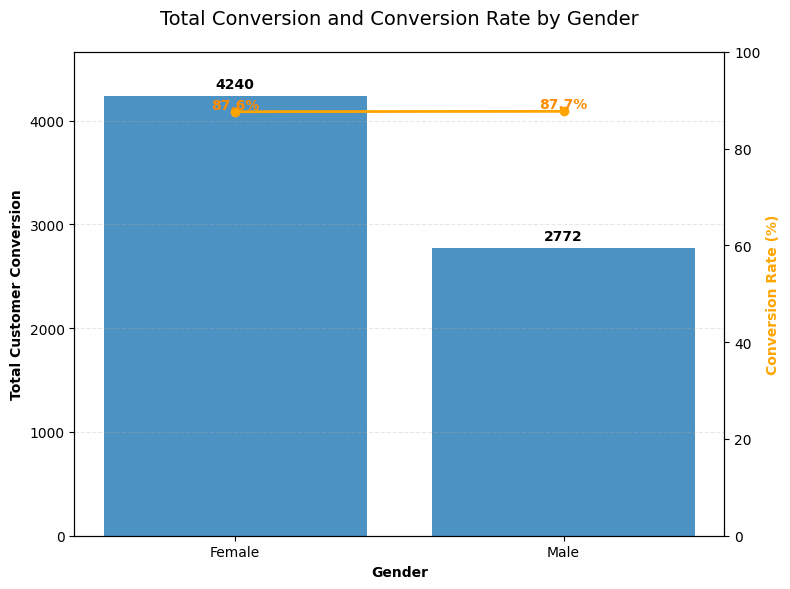

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# 1. Bar Chart (Total Conversion)
bars = ax1.bar(
    df_gender['Gender'],
    df_gender['Total_Conversion'],
    color='tab:blue',
    alpha=0.8
)
ax1.set_ylabel('Total Customer Conversion', fontweight='bold')
ax1.set_xlabel('Gender', fontweight='bold')
ax1.set_title('Total Conversion and Conversion Rate by Gender', pad=20, fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.3)


ax1.set_ylim(0, df_gender['Total_Conversion'].max() * 1.1)

# 2. Line Chart (Conversion Rate) - Gunakan sumbu Y kedua
ax2 = ax1.twinx()
line = ax2.plot(
    df_gender['Gender'],
    df_gender['Conversion_Rate'],
    marker='o',
    color='orange',
    linewidth=2,
    label='Conversion Rate'
)
ax2.set_ylabel('Conversion Rate (%)', color='orange', fontweight='bold')


ax2.set_ylim(0, 100)

# 3. Memberi Label Angka di atas Bar
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# 4. Memberi Label Persentase di dekat Titik Line
for i, value in enumerate(df_gender['Conversion_Rate']):
    ax2.text(
        i,
        value + 0.01,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        color='darkorange',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

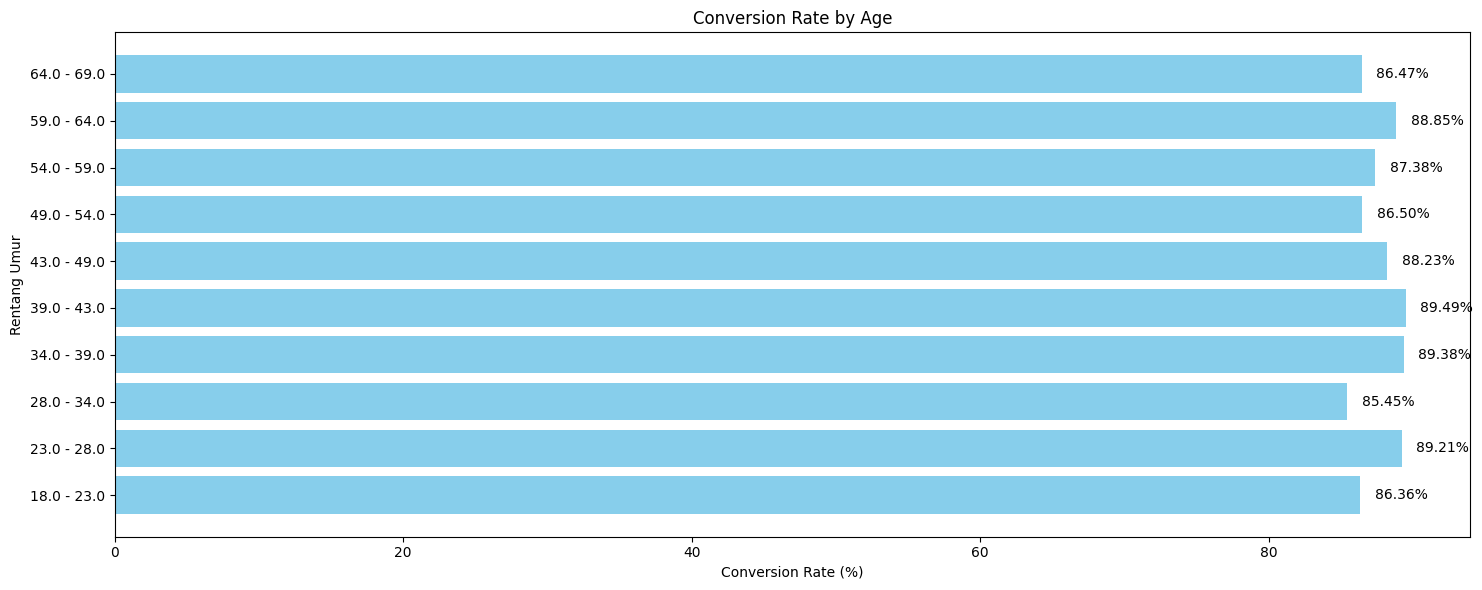

In [ ]:
# Berdasarkan Age (Umur)
df_gender = df.groupby('Gender').agg(
    Total_Customer=('CustomerID', 'count'),
    Total_Conversion = ('Conversion', 'sum'),
    Conversion_Rate = ('Conversion', 'mean')
).reset_index()

df_gender['Conversion_Rate'] = df_gender['Conversion_Rate'] * 100

df_gender

fig, ax = plt.subplots(figsize=(15, 6))

bars = ax.barh(df_results['Age']['Age_range'], df_results['Age']['Conversion Rate (%)'], color='skyblue')

# Menambahkan label dan judul
ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('Rentang Umur')
ax.set_title('Conversion Rate by Age')

# Opsional: Menambahkan angka di ujung batang
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}%', va='center')

plt.tight_layout()
plt.show()

          Income_range  Conversion Rate (%)
0    20014.0 - 32436.0               86.625
1    32436.0 - 45057.6               85.875
2    45057.6 - 58900.0               88.375
3    58900.0 - 71597.4               88.250
4    71597.4 - 84926.5               87.625
5    84926.5 - 98508.0               87.875
6   98508.0 - 110503.8               87.375
7  110503.8 - 123430.0               88.500
8  123430.0 - 136216.2               87.375
9  136216.2 - 149986.0               88.625


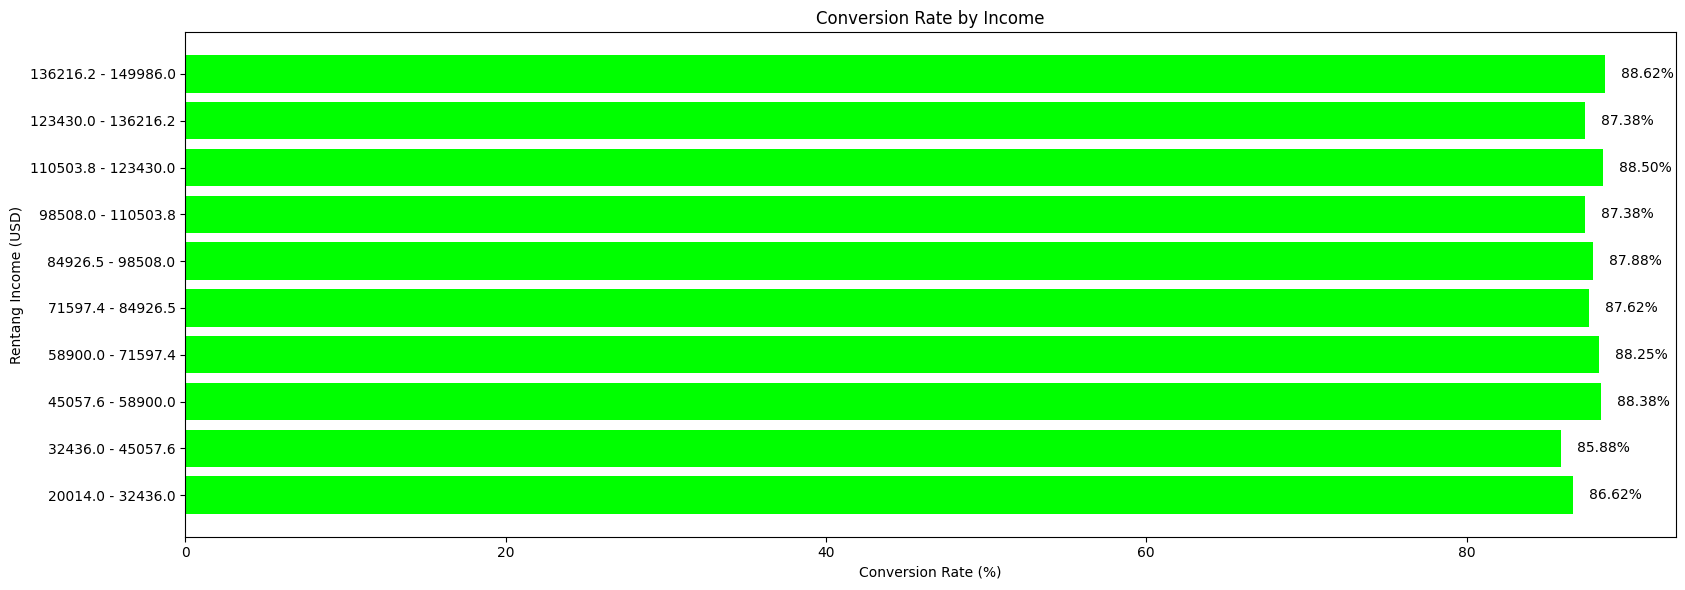

In [ ]:
# Berdasarkan Income
print(df_results['Income'])

fig, ax = plt.subplots(figsize=(17, 6))

bars = ax.barh(df_results['Income']['Income_range'], df_results['Income']['Conversion Rate (%)'], color='Lime')

# Menambahkan label dan judul
ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('Rentang Income (USD)')
ax.set_title('Conversion Rate by Income')

# Opsional: Menambahkan angka di ujung batang
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}%', va='center')

plt.tight_layout()
plt.show()

**Insight**

Hasil segmentasi berdasarkan faktor demografis seperti gender, usia, dan pendapatan menunjukkan bahwa conversion rate antar kelompok relatif serupa dan tidak memiliki perbedaan signifikan. Hal ini mengindikasikan bahwa demografi belum cukup efektif untuk membedakan kualitas pelanggan. Oleh karena itu, diperlukan analisis lanjutan berbasis customer engagement guna mengidentifikasi pelanggan yang lebih potensial, sehingga strategi customer pruning dapat dilakukan secara lebih tepat dan efisien.

#### b. Berdasarkan Customer Engagement (Interaktivitas Customer)

In [ ]:
cust_engagement = ['HistoryCR', 'ClickThroughRate','WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdSpend']

for i in cust_engagement:
  print(f"==== Conversion Rate (%) by {i} ====")
  print(df_results[i].to_string(index=False))

==== Conversion Rate (%) by HistoryCR ====
HistoryCR_range  Conversion Rate (%)
    0.01 - 0.03               78.875
    0.03 - 0.05               78.125
    0.05 - 0.07               89.250
    0.07 - 0.08               90.625
     0.08 - 0.1               91.125
     0.1 - 0.12               89.250
    0.12 - 0.14               89.875
    0.14 - 0.16               90.500
    0.16 - 0.18               90.125
     0.18 - 0.2               88.750
==== Conversion Rate (%) by ClickThroughRate ====
ClickThroughRate_range  Conversion Rate (%)
           0.01 - 0.04               80.750
           0.04 - 0.07               80.375
            0.07 - 0.1               79.875
            0.1 - 0.13               90.000
           0.13 - 0.16               90.375
           0.16 - 0.18               91.250
           0.18 - 0.21               91.000
           0.21 - 0.24               89.625
           0.24 - 0.27               91.500
            0.27 - 0.3               91.750
==== Conversion 

/tmp/ipykernel_569/3836381591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_569/3836381591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_569/3836381591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_569/3836381591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_569/3836381591.py:19: Fut

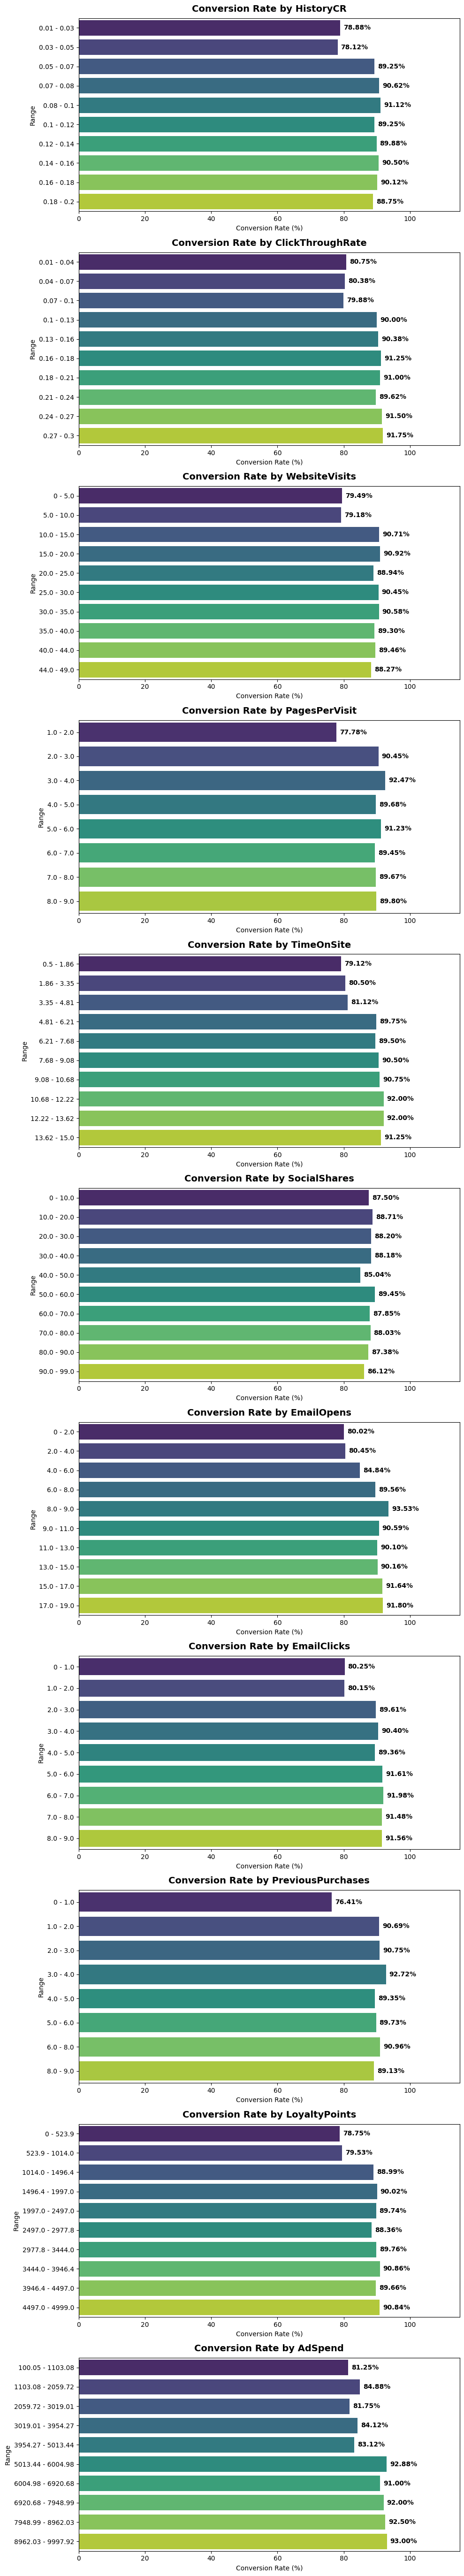

In [ ]:

# 1. Daftar visualisasi kolom engagment
cust_engagement = ['HistoryCR', 'ClickThroughRate','WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdSpend']

# 2. Siapkan plot (n baris, 1 kolom)
n_metrics = len(cust_engagement)
fig, axes = plt.subplots(nrows=n_metrics, ncols=1, figsize=(10, 5 * n_metrics))

# 3. Looping untuk membuat chart satu per satu
for i, col in enumerate(cust_engagement):
    # Pastikan metrik ada di df_results
    if col in df_results:
        df_plot = df_results[col]

        # Cari nama kolom range
        range_col = [c for c in df_plot.columns if '_range' in c][0]
        cr_col = 'Conversion Rate (%)'

        # Gambar di axis yang bersangkutan (axes[i])
        ax = sns.barplot(
            x=cr_col,
            y=range_col,
            data=df_plot,
            ax=axes[i],
            palette='viridis'
        )

        # Tambahkan label angka di ujung bar
        for p in ax.patches:
            width = p.get_width()
            ax.annotate(f'{width:.2f}%',
                        (width + 1, p.get_y() + p.get_height()/2),
                        va='center', fontsize=10, fontweight='bold')

        # Label dan Judul
        ax.set_title(f'Conversion Rate by {col}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlim(0, 115)
        ax.set_xlabel('Conversion Rate (%)')
        ax.set_ylabel('Range')
    else:
        # Jika metrik tidak ditemukan, sembunyikan axis kosongnya
        axes[i].axis('off')

# 4. Atur jarak antar grafik
plt.tight_layout()
plt.show()

**Insight**

- Secara umum, **semakin tinggi tingkat customer engagement, semakin tinggi pula conversion rate yang dihasilkan**. Pelanggan dengan tingkat engagement rendah cenderung memiliki conversion rate di kisaran 78–81%, sedangkan pelanggan dengan engagement yang lebih tinggi mampu mencapai lebih dari 90%. Hal ini menunjukkan adanya hubungan yang kuat antara tingkat interaksi pelanggan dengan kemungkinan terjadinya konversi.

- **History Conversion Rate** : Tingkat konversi tertinggi berada pada segmen 0.08 - 0.1 dengan angka 91.12%
- **ClickThroughRate** : Tingkat konversi tertinggi dicapai oleh pelanggan di segmen 0.27 - 0.3 dengan angka 91.75% (Tren positif semakin tinggi CTR, semakin tinggi conversion rate.
- **WebsiteVisits** : Tingkata konversi tertinggi dicapai oleh pelanggan yang mengunjungi website sebanyak 15 - 20 kali
- **PagesPerVisit** : Tingkat konversi tertinggi dicapai pada segmen 3.0 - 4.0 halaman dengan angka 92.47%. Semakin dalam pengguna mengeksplorasi konten situs (hingga 4 halaman), semakin tinggi pelanggan untuk melakukan konversi
- **TimeOnSite** : Puncak konversi berada pada rentang 10.68 - 13.62 menit dengan angka mencapai 92.00%. Durasi di atas 10 menit mengindikasikan keterlibatan (engagement) yang sangat tinggi, yang secara langsung berujung pada performa konversi maksimal.
- **SocialShares** : Customer yang melakukan share sebanyak 10-20 kali memiliki nilai conversion rate paling tinggi (88.71%). Namun, tidak terdapat perbedaan signifikan antar kategori yang lain sehingga variabel ini tidak terlalu berpengaruh terhadap conversion rate
- **EmailOpens** : Tingkat konversi tertinggi dicapai oleh pelanggan yang membuka email sebanyak 8 - 9 kali (93.53%). Hal ini mengindikasikan bahwa frekuensi customer yang membuka email secara konsisten sangat efektif dalam mendorong keputusan pembelian.
- **EmailClicks** : pelanggan yang melakukan minimal 2 klik dalam kampanye email adalah kunci untuk meningkatkan peluang konversi hingga di atas 89%.
- **PreviousPurchases** : Puncak konversi berada pada pelanggan yang memiliki riwayat 3 - 4 pembelian dengan angka 92.72%. Pelanggan yang sudah pernah belanja sebelumnya lebih mudah untuk melakukan konversi daripada pelanggan baru.
- **LoyaltyPoints** : Pelanggan yang memiliki point loyalitas minimal 1000 memiliki nilai conversion rate yang stabil (>88%). Keputusan pembelian pelanggan terlihat saat mereka sudah mengumpulkan lebih dari 1000 poin.
- **AdSpend** : Terdapat tren yang jelas bahwa peningkatan anggaran iklan (AdSpend) berbanding lurus dengan kenaikan tingkat konversi. Ini menunjukkan bahwa strategi penargetan iklan semakin efektif pada skala anggaran yang lebih besar.Tingkat konversi tertinggi dicapai pada segmen anggaran maksimal (8962.03 - 9997.92) dengan angka 93.00%

#### c. Berdasarkan Marketing Campaign (CampaignChannel & CampaignType)

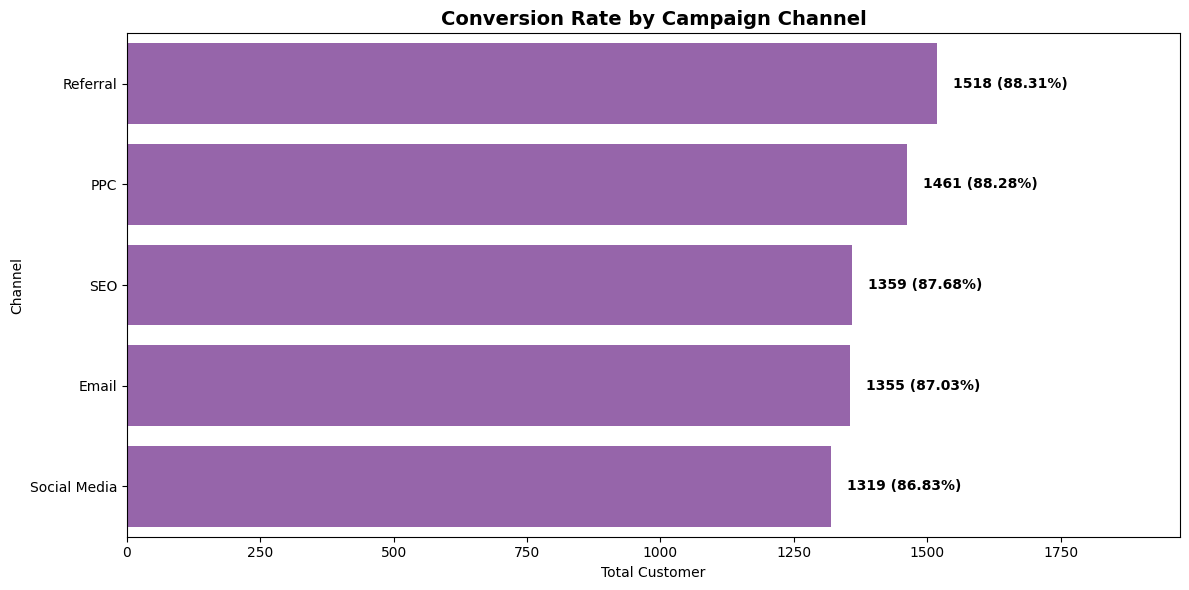

In [ ]:
# --- ANALYSIS: CAMPAIGN CHANNEL ---
df_converted_only = df[df['Conversion'] == 1]
plt.figure(figsize=(12, 6))

# Menghitung volume dan urutan berdasarkan data yang sudah konversi
counts_channel = df_converted_only['CampaignChannel'].value_counts()
order_channel = counts_channel.index

# Menghitung mean conversion rate dari dataframe asli (df) untuk akurasi persentase
mean_channel = df.groupby('CampaignChannel')['Conversion'].mean()

# Visualisasi
ax = sns.countplot(data=df_converted_only, y='CampaignChannel', order=order_channel, color='#9B59B6')

plt.title('Conversion Rate by Campaign Channel', fontsize=14, fontweight='bold')
plt.xlabel('Total Customer')
plt.ylabel('Channel')

# Menambahkan label angka (Volume) dan persentase (Conversion Rate)
for p in ax.patches:
    # Mendapatkan nama kategori berdasarkan posisi bar
    current_width = p.get_width()
    if current_width > 0: # Memastikan bar memiliki nilai
        # Mengambil label kategori yang sesuai dengan urutan y-axis
        cat = order_channel[int(p.get_y() + 0.5)]
        rate = mean_channel[cat] * 100

        label = f'{int(current_width)} ({rate:.2f}%)' # Menggunakan 2 desimal agar lebih bersih
        ax.text(current_width + (counts_channel.max() * 0.02),
                p.get_y() + p.get_height()/2,
                label, va='center', fontweight='bold')

plt.xlim(0, counts_channel.max() * 1.3)
plt.tight_layout()
plt.show()

**Insight**
- **Referral sebagai High-Intent Driver**: Channel ini memimpin dengan Conversion Rate tertinggi (88.31%) dan jumlah customer terbanyak (1.518). Ini membuktikan bahwa strategi berbasis kepercayaan (seperti word-of-mouth atau partner) adalah senjata paling ampuh untuk menghasilkan konversi berkualitas.
- **PPC sangat kompetitif dengan Referral** : Meskipun biasanya membutuhkan biaya iklan (ads spend), channel ini terbukti sangat efektif dalam mendapatkan customer yang siap melakukan transaksi secara instan.
- **Social Media sebagai Peluang Scale-Up** : Walaupun berada di posisi terbawah (86.83%), selisih konversinya tidak terpaut jauh dari channel lainnya. Social Media tetap menjadi channel krusial untuk menjaga brand awareness dan jangkauan audiens yang luas (top of the funnel).

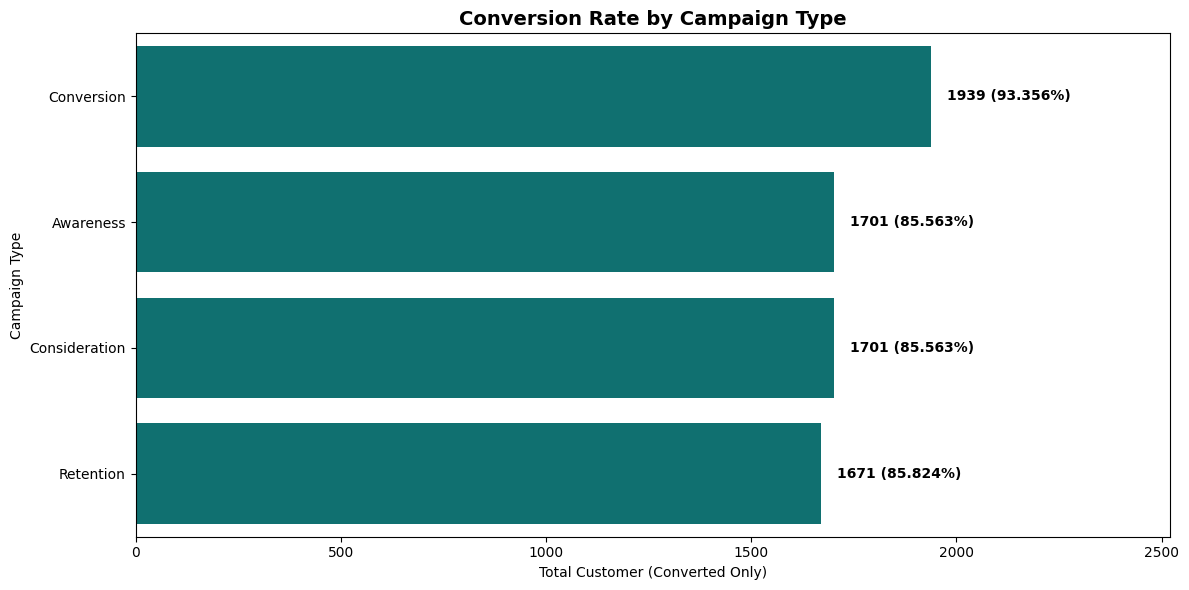

In [ ]:
# --- ANALYSIS: CAMPAIGN TYPE ---
plt.figure(figsize=(12, 6))

counts_type = df_converted_only['CampaignType'].value_counts()
order_type = counts_type.index
mean_type = df.groupby('CampaignType')['Conversion'].mean()

ax = sns.countplot(data=df_converted_only, y='CampaignType', order=order_type, color='#008080')

plt.title('Conversion Rate by Campaign Type', fontsize=14, fontweight='bold')
plt.xlabel('Total Customer (Converted Only)')
plt.ylabel('Campaign Type')

for p in ax.patches:
    cat = order_type[int(p.get_y() + 0.5)]
    val = p.get_width()
    rate = mean_type[cat] * 100

    label = f'{int(val)} ({rate:.3f}%)'
    ax.text(val + (counts_type.max() * 0.02),
            p.get_y() + p.get_height()/2,
            label, va='center', fontweight='bold')

plt.xlim(0, counts_type.max() * 1.3)
plt.tight_layout()
plt.show()

**Insight**
- **Dominasi tipe campaign Conversion sebagai profit utama** : Campaign tipe Conversion memiliki volume customer tertinggi (1.939) dan juga mencapai nilai CR sebesar 93,36% yang menunjukkan efisiensi yang tinggi. Ini mengindikasikan bahwa funneling pada tahap akhir sudah sangat optimal.
- **Potensi pada Retention yang perlu ditingkatkan** : Retention memiliki volume customer terendah (1.671). Meskipun CR-nya stabil (85,82%), angka ini cukup rendah untuk kampanye yang menargetkan pelanggan lama. Secara teori, biaya akuisisi pelanggan lama lebih murah; rendahnya volume ini menunjukkan perlunya strategi re-engagement yang lebih agresif untuk memaksimalkan Customer Lifetime Value (CLV).

#### ===================== SUMMARY =====================

/tmp/ipykernel_569/3844291904.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_top5, x='Conversion Rate (%)', y='Full_Label', palette='viridis')


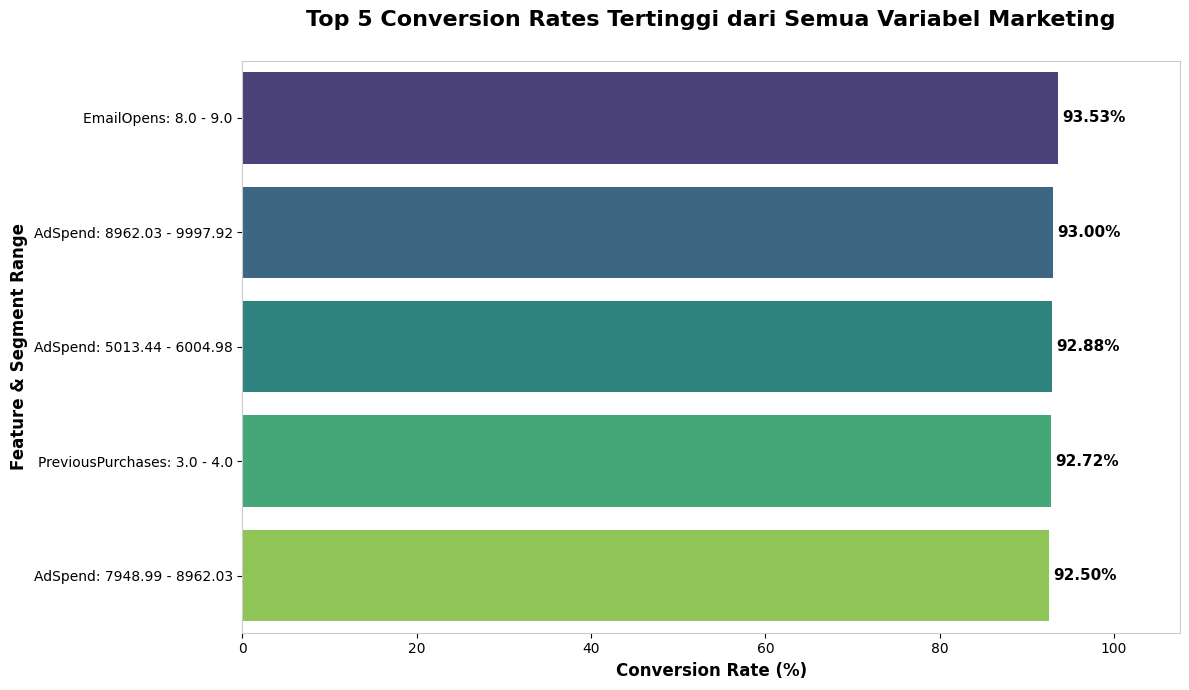

==== SUMMARY TABLE: TOP 5 PERFORMANCE SEGMENTS ====


,Source_Column,Segment_Value,Conversion Rate (%)
0,EmailOpens,8.0 - 9.0,93.533487
1,AdSpend,8962.03 - 9997.92,93.000000
2,AdSpend,5013.44 - 6004.98,92.875000
3,PreviousPurchases,3.0 - 4.0,92.722710
4,AdSpend,7948.99 - 8962.03,92.500000


In [ ]:
# --- 1. AGREGASI DATA CONVERSION RATE DARI SELURUH FITUR ---
all_cr_data = []

# Iterasi melalui dictionary hasil grouping untuk menyatukan metrik ke dalam satu struktur data
for col, data in df_results.items():
    temp_df = data.copy()

    # Menambahkan metadata kolom asal untuk keperluan identifikasi variabel
    temp_df['Source_Column'] = col

    # Standarisasi label kategori/range menggunakan indexing posisi kolom pertama
    temp_df['Segment_Value'] = temp_df.iloc[:, 0]

    # Seleksi atribut relevan: Nama Fitur, Nilai Segmen, dan Metrik Persentase Konversi
    temp_df = temp_df[['Source_Column', 'Segment_Value', 'Conversion Rate (%)']]

    all_cr_data.append(temp_df)

# Menggabungkan seluruh dataframe hasil iterasi menjadi satu master dataframe
df_all_compiled = pd.concat(all_cr_data, ignore_index=True)

# --- 2. IDENTIFIKASI TOP 5 SEGMEN BERKINERJA TERTINGGI (BEST PERFORMERS) ---
# Mengurutkan data berdasarkan efisiensi konversi secara descending
df_top5 = df_all_compiled.sort_values(by='Conversion Rate (%)', ascending=False).head(5).reset_index(drop=True)

# Membuat label komposit untuk visualisasi sumbu Y (Variabel: Rentang Nilai)
df_top5['Full_Label'] = df_top5['Source_Column'] + ": " + df_top5['Segment_Value'].astype(str)

# --- 3. VISUALISASI PERBANDINGAN STRATEGIS (TOP 5 CR) ---
plt.figure(figsize=(12, 7))
# Implementasi palette 'viridis' untuk merepresentasikan gradasi performa secara visual
ax = sns.barplot(data=df_top5, x='Conversion Rate (%)', y='Full_Label', palette='viridis')

# --- 4. KONFIGURASI ESTETIKA & INFORMASI GRAFIK ---
plt.title('Top 5 Conversion Rates Tertinggi dari Semua Variabel Marketing', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Feature & Segment Range', fontsize=12, fontweight='bold')

# Implementasi Label Data (Data Labels) pada setiap ujung bar untuk presisi informasi
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2,
            f'{width:.2f}%', va='center', fontweight='bold', fontsize=11)

# Pengaturan batas bingkai (spines) untuk meningkatkan keterbacaan (readability)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#CCCCCC')

plt.xlim(0, df_top5['Conversion Rate (%)'].max() * 1.15)
plt.tight_layout()
plt.show()

# --- 5. OUTPUT SUMMARY TABLE ---
print("==== SUMMARY TABLE: TOP 5 PERFORMANCE SEGMENTS ====")
display(df_top5[['Source_Column', 'Segment_Value', 'Conversion Rate (%)']])

### 2. Variabel mana yang paling efektif dalam  membedakan customer potensial dan customer tidak produktif?

In [ ]:
# --- 1. AGREGASI DATA KATEGORIKAL (CAMPAIGN ATTRIBUTES) ---
col_cat = ['CampaignType', 'CampaignChannel']

for col in col_cat:
    # Menghitung rerata konversi untuk mengevaluasi efektivitas setiap kanal/tipe kampanye
    temp = df.groupby(col).agg(conversion_rate=('Conversion', 'mean')).reset_index()
    temp['Conversion Rate (%)'] = temp['conversion_rate'] * 100

    # Standarisasi skema penamaan kolom untuk integrasi data
    temp.rename(columns={col: f"{col}_range"}, inplace=True)
    df_results[col] = temp[[f"{col}_range", 'Conversion Rate (%)']]

# --- 2. ANALISIS SENSITIVITAS & DIAGNOSTIK GAP (DETEKSI INEFISIENSI) ---
# Tabel ini bertujuan mengidentifikasi variabel dengan daya pembeda (discriminatory power) tertinggi
sensitivity_diagnostics = []

for col, data in df_results.items():
    # Kalkulasi rentang (gap) untuk menentukan variabel mana yang paling efektif
    # dalam memisahkan segmen potensial dan segmen tidak produktif
    max_cr = data['Conversion Rate (%)'].max()
    min_cr = data['Conversion Rate (%)'].min()

    sensitivity_diagnostics.append({
        'Feature_Variable': col,
        'Min_Performance (%)': min_cr,
        'Max_Performance (%)': max_cr,
        'Conversion_Gap': max_cr - min_cr
    })

# Konstruksi DataFrame Final untuk Penentuan Prioritas Pruning
# Variabel dengan 'Conversion_Gap' tertinggi adalah detektor inefisiensi terbaik
pruning_diagnostic_df = pd.DataFrame(sensitivity_diagnostics).sort_values(by='Conversion_Gap', ascending=False)

# Menampilkan hasil analisis diagnostik
pruning_diagnostic_df

,Feature_Variable,Min_Performance (%),Max_Performance (%),Conversion_Gap
11,PreviousPurchases,76.409314,92.722710,16.313396
6,PagesPerVisit,77.777778,92.471910,14.694132
9,EmailOpens,80.017153,93.533487,13.516335
4,HistoryCR,78.125000,91.125000,13.000000
7,TimeOnSite,79.125000,92.000000,12.875000
12,LoyaltyPoints,78.750000,90.863579,12.113579
3,ClickThroughRate,79.875000,91.750000,11.875000
10,EmailClicks,80.146163,91.975309,11.829145
2,AdSpend,81.250000,93.000000,11.750000
5,WebsiteVisits,79.177378,90.919674,11.742296


**Insight**

Variabel yang paling efektif antara pelanggan potensial dan pelanggan tidak produktif adalah **PreviousPurchases** (Riwayat Pembelian)

- Memiliki Conversion Gap terbesar (16,31%), dengan rentang performa dari 76,4% (rendah) hingga 92,7% (sangat tinggi).
- Variabel ini merupakan indikator perilaku (behavioral) yang paling kontras.Pelanggan yang sudah memiliki riwayat transaksi menunjukkan kepercayaan dan niat beli yang jauh lebih tinggi dibandingkan pelanggan baru.

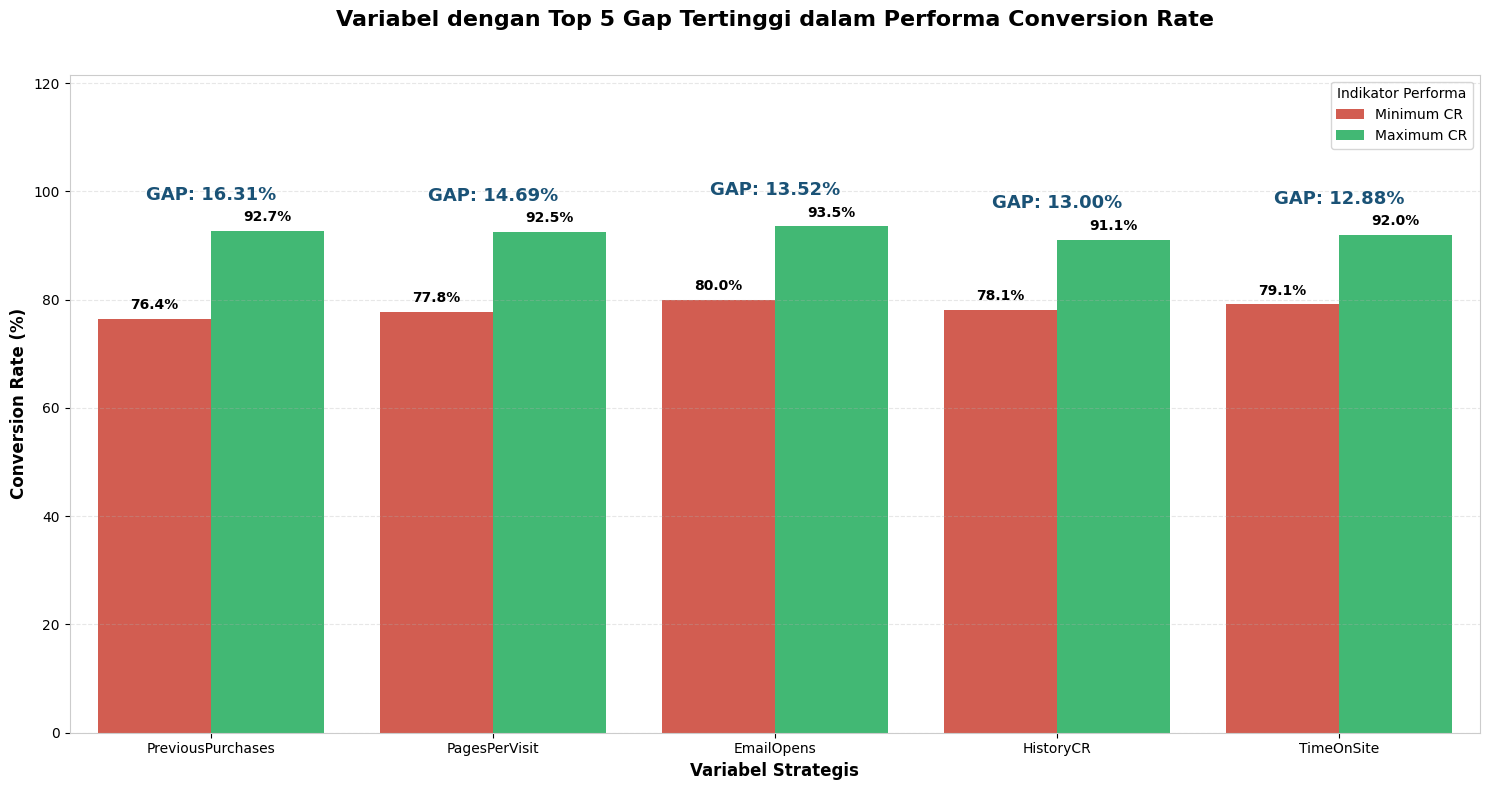

In [ ]:
# --- 1. DATA PREPARATION: TOP 5 CONVERSION GAP ---
# Mengambil 5 variabel dengan indeks sensitivitas (Conversion Gap) tertinggi
df_plot_gap = pruning_diagnostic_df.head(5).copy()

# Transformasi struktur data (Melting) untuk kebutuhan visualisasi Grouped Bar Chart
df_melted = df_plot_gap.melt(
    id_vars=['Feature_Variable', 'Conversion_Gap'],
    value_vars=['Min_Performance (%)', 'Max_Performance (%)'],
    var_name='Performance_Type',
    value_name='CR_Percentage'
)

# Standarisasi label kategori untuk meningkatkan keterbacaan (Readability)
df_melted['Performance_Type'] = df_melted['Performance_Type'].replace({
    'Min_Performance (%)': 'Minimum CR',
    'Max_Performance (%)': 'Maximum CR'
})

# --- 2. STRATEGIC VISUALIZATION: GROUPED BAR CHART ---
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_melted,
    x='Feature_Variable',
    y='CR_Percentage',
    hue='Performance_Type',
    palette=['#E74C3C', '#2ECC71'] # Skema warna komparatif (Low vs High Performance)
)

# --- 3. DATA LABELING: METRIKS PERFORMA & DELTA (GAP) ---
# Implementasi anotasi nilai absolut pada masing-masing bar (Min & Max)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

# Visualisasi metrik GAP sebagai indikator utama sensitivitas variabel
# Penekanan dilakukan melalui ukuran font dan kontras warna (Biru Safir)
for i, v in enumerate(df_plot_gap['Feature_Variable']):
    max_val = df_plot_gap.iloc[i]['Max_Performance (%)']
    gap_val = df_plot_gap.iloc[i]['Conversion_Gap']

    # Penempatan label GAP secara strategis di atas bar tertinggi
    ax.text(i, max_val + 5, f'GAP: {gap_val:.2f}%',
            ha='center', va='bottom',
            fontsize=13,
            fontweight='black',
            color='#1A5276')

# --- 4. GRAPHICAL OPTIMIZATION & AESTHETICS ---
plt.title('Variabel dengan Top 5 Gap Tertinggi dalam Performa Conversion Rate', fontsize=16, fontweight='bold', pad=35)
plt.ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Variabel Strategis', fontsize=12, fontweight='bold')
plt.legend(title='Indikator Performa', loc='upper right')

# Konfigurasi bingkai (Spines) dan grid untuk estetika profesional
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#CCCCCC')

# Adjustmen skala sumbu Y guna mengakomodasi label informasi agar tidak terpotong (Clipping)
plt.ylim(0, df_plot_gap['Max_Performance (%)'].max() * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**
- **Indikator engagement berdampak tinggi** : Dari 15 variabel engagement, terdapat 5 variabel utama yang memiliki gap terbesar (PreviousPurchases, PagesPerVisit, EmailOpens, HistoryCR, dan TimeOnSite) semuanya merupakan metrik keterlibatan pelanggan (engagement).
- **Pola Threshold Konversi** : Kelima variabel tersebut menunjukkan performa maksimum yang konsisten di angka 91% - 93%. Namun, variansi yang signifikan pada nilai minimum conversion rate mengindikasikan bahwa alokasi anggaran pada pelanggan dengan interaksi rendah cenderung tidak efisien. Untuk mengoptimalkan biaya pemasaran, perlu dilakukan simulasi *Customer Pruning* dengan mengeliminasi segmen pelanggan tidak produktif (segment dengan CR minimum) dari target pemasaran.


### 3. Bagaimana efektivitas berbagai variabel dalam menghasilkan peningkatan Conversion Rate yang optimal melalui metode prospek pruning?

Analisis selanjutnya adalah melakukan simulasi Customer Pruning pada lima variabel dengan Gap Conversion tertinggi, yaitu PreviousPurchases, PagesPerVisit, EmailOpens, HistoryCR, dan TimeOnSite. Pemilihan kelima kategori ini didasarkan pada signifikansi dampak mereka terhadap efisiensi operasional dengan mengeliminasi (dropping) segmen pelanggan yang berada pada kategori performa minimum di variabel-variabel tersebut, perusahaan dapat memitigasi pemborosan anggaran iklan (ad spend) dan memfokuskan sumber daya pada segmen yang memiliki probabilitas konversi di atas 90%.

#### Berdasarkan kolom `PreviousPurchases`



/tmp/ipykernel_569/2543015536.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pp_stats = df_bins.groupby('PreviousPurchases_range')['Conversion'].mean().reset_index()
/tmp/ipykernel_569/2543015536.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=rates, palette='Blues_r', ax=ax1, alpha=0.7)


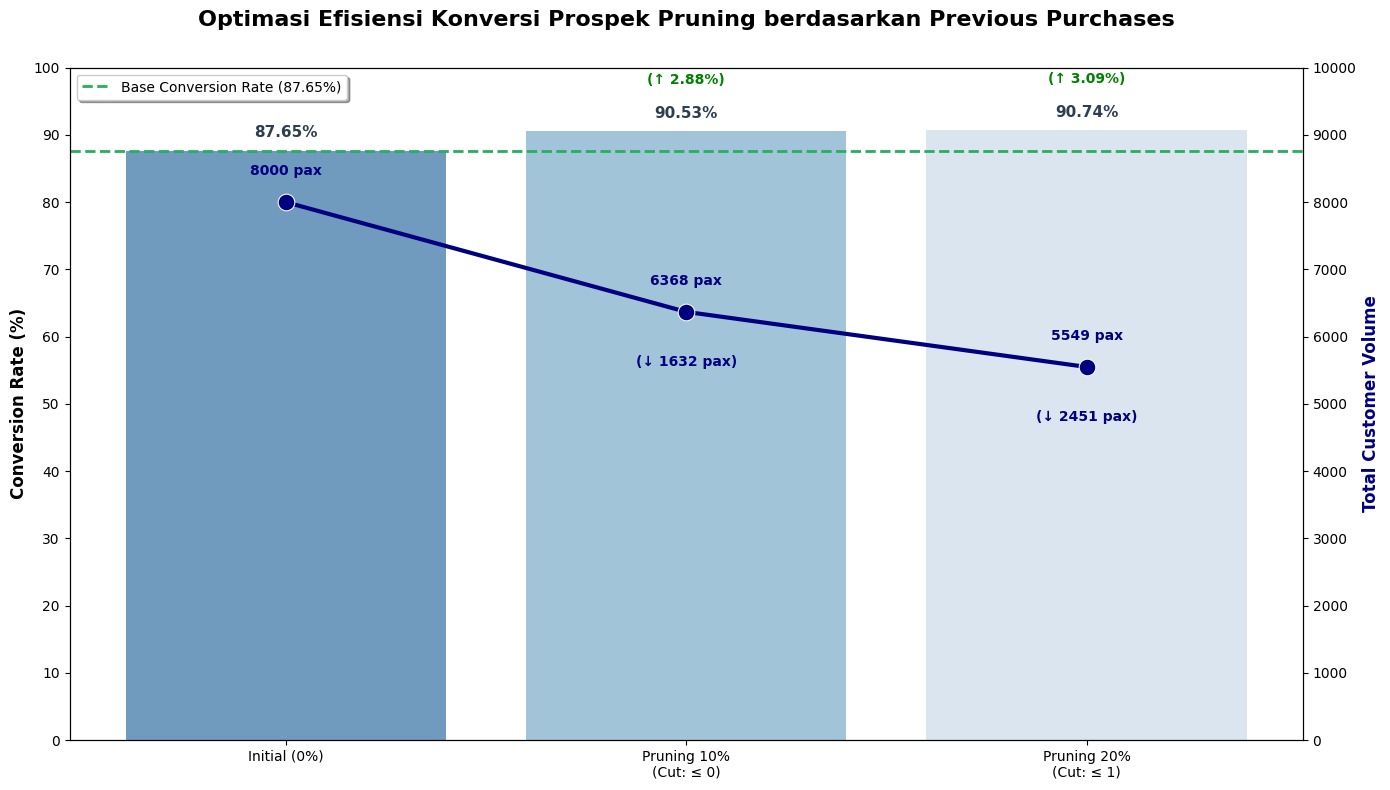

In [ ]:
# --- 1. PERHITUNGAN DATA (LOGIKA DYNAMIC PRUNING - PREVIOUS PURCHASES) ---
# Grouping berdasarkan range untuk mencari segmen terburuk
df_pp_stats = df_bins.groupby('PreviousPurchases_range')['Conversion'].mean().reset_index()

# Baseline (Kondisi Awal)
cr_0 = df['Conversion'].mean() * 100
vol_0 = len(df)

# SORTING UNTUK CARI TERBURUK
df_sorted = df_pp_stats.sort_values(by='Conversion')

# REMOVE 10% (1 SEGMENT TERBURUK)
lowest_segment = df_sorted.iloc[0]['PreviousPurchases_range']
df10_pp = df_bins[df_bins['PreviousPurchases_range'] != lowest_segment]

cr_10 = df10_pp['Conversion'].mean() * 100
vol_10 = len(df10_pp)

# REMOVE 20% (2 SEGMENT TERBURUK)
lowest_segments_2 = df_sorted.head(2)['PreviousPurchases_range'].tolist()
df20_pp = df_bins[~df_bins['PreviousPurchases_range'].isin(lowest_segments_2)]

cr_20 = df20_pp['Conversion'].mean() * 100
vol_20 = len(df20_pp)

# FORMAT LABEL
scenarios = [
    'Initial (0%)',
    'Pruning 10%\n(Cut: ≤ 0)',
    'Pruning 20%\n(Cut: ≤ 1)'
]

rates = [cr_0, cr_10, cr_20]
volumes = [vol_0, vol_10, vol_20]

# Delta (Selisih)
diff_rate_10 = cr_10 - cr_0
diff_rate_20 = cr_20 - cr_0
diff_vol_10 = vol_0 - vol_10
diff_vol_20 = vol_0 - vol_20

# --- 2. VISUALISASI  ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# BAR CHART
sns.barplot(x=scenarios, y=rates, palette='Blues_r', ax=ax1, alpha=0.7)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 101, 10))
ax1.grid(False)

# Annotasi Bar
for i, v in enumerate(rates):
    ax1.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', color='#2C3E50', fontsize=11)
    if i == 1:
        ax1.text(i, v + 7, f'(↑ {diff_rate_10:.2f}%)', ha='center', color='green', fontweight='bold')
    if i == 2:
        ax1.text(i, v + 7, f'(↑ {diff_rate_20:.2f}%)', ha='center', color='green', fontweight='bold')

# LINE CHART
ax2 = ax1.twinx()
sns.lineplot(x=scenarios, y=volumes, marker='o', markersize=12, color='#000080', linewidth=3, ax=ax2)
ax2.set_ylabel('Total Customer Volume', fontsize=12, fontweight='bold', color='#000080')
ax2.set_ylim(0, 10000)
ax2.set_yticks(np.arange(0, 10001, 1000))
ax2.grid(False)

# Annotasi Garis
for i, v in enumerate(volumes):
    ax2.text(i, v + 400, f'{int(v)} pax', ha='center', fontweight='bold', color='#000080')
    if i == 1:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_10)} pax)', ha='center', color='#000080', fontweight='bold')
    if i == 2:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_20)} pax)', ha='center', color='#000080', fontweight='bold')

# Target Line
ax1.axhline(87.65, color='#27AE60', linestyle='--', linewidth=2, label='Base Conversion Rate (87.65%)')

plt.title('Optimasi Efisiensi Konversi Prospek Pruning berdasarkan Previous Purchases', fontsize=16, fontweight='bold', pad=30)
ax1.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

#### Berdasarkan kolom `PagesPerVisit`

/tmp/ipykernel_569/2552376495.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ppv_stats = df_bins.groupby('PagesPerVisit_range')['Conversion'].mean().reset_index()
/tmp/ipykernel_569/2552376495.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=rates, palette='magma', ax=ax1, alpha=0.7)


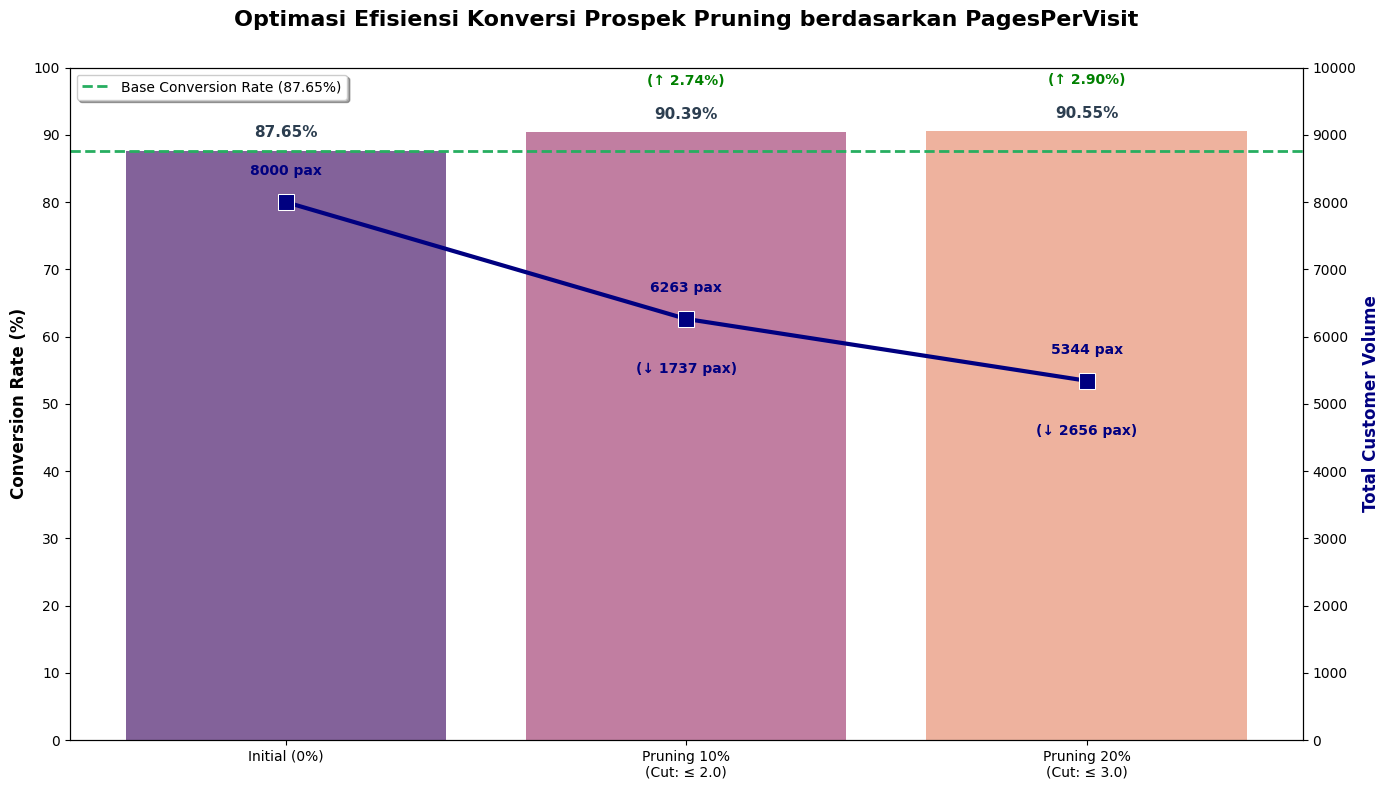

In [ ]:
# --- 1. PERHITUNGAN DATA (LOGIKA DYNAMIC PRUNING) ---
df_ppv_stats = df_bins.groupby('PagesPerVisit_range')['Conversion'].mean().reset_index()

cr_0 = df['Conversion'].mean() * 100
vol_0 = len(df)

# Sort untuk cari segmen dengan CR terendah (Otomatis dapet yang 77%)
df_sorted = df_ppv_stats.sort_values(by='Conversion')

# --- PRUNING 10% ---
lowest_segment_1 = df_sorted.iloc[0]['PagesPerVisit_range']
# Ambil angka belakang dari string '1.0 - 2.0' -> 2.0
t10_val = float(lowest_segment_1.split(' - ')[1])

df10 = df_bins[df_bins['PagesPerVisit_range'] != lowest_segment_1]
cr_10 = df10['Conversion'].mean() * 100
vol_10 = len(df10)

# --- PRUNING 20% ---
lowest_segments_2 = df_sorted.head(2)['PagesPerVisit_range'].tolist()
# Ambil angka belakang dari segmen KEDUA terburuk ('2.0 - 3.0' -> 3.0)
last_segment_text = df_sorted.iloc[1]['PagesPerVisit_range']
t20_val = float(last_segment_text.split(' - ')[1])

df20 = df_bins[~df_bins['PagesPerVisit_range'].isin(lowest_segments_2)]
cr_20 = df20['Conversion'].mean() * 100
vol_20 = len(df20)

# --- FORMAT LABEL X ---
scenarios = [
    'Initial (0%)',
    'Pruning 10%\n(Cut: ≤ 2.0)',
    'Pruning 20%\n(Cut: ≤ 3.0)'
]

rates = [cr_0, cr_10, cr_20]
volumes = [vol_0, vol_10, vol_20]

# Delta
diff_rate_10 = cr_10 - cr_0
diff_rate_20 = cr_20 - cr_0
diff_vol_10 = vol_0 - vol_10
diff_vol_20 = vol_0 - vol_20

# --- 2. VISUALISASI STRATEGIS (FORMAT KODE PERTAMA) ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# BAR CHART
sns.barplot(x=scenarios, y=rates, palette='magma', ax=ax1, alpha=0.7)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 101, 10))
ax1.grid(False)

# Annotasi Bar
for i, v in enumerate(rates):
    ax1.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', color='#2C3E50', fontsize=11)
    if i == 1:
        ax1.text(i, v + 7, f'(↑ {diff_rate_10:.2f}%)', ha='center', color='green', fontweight='bold')
    if i == 2:
        ax1.text(i, v + 7, f'(↑ {diff_rate_20:.2f}%)', ha='center', color='green', fontweight='bold')

# LINE CHART
ax2 = ax1.twinx()
sns.lineplot(x=scenarios, y=volumes, marker='s', markersize=12, color='#000080', linewidth=3, ax=ax2)
ax2.set_ylabel('Total Customer Volume', fontsize=12, fontweight='bold', color='#000080')
ax2.set_ylim(0, 10000)
ax2.set_yticks(np.arange(0, 10001, 1000))
ax2.grid(False)

# Annotasi Garis
for i, v in enumerate(volumes):
    ax2.text(i, v + 400, f'{int(v)} pax', ha='center', fontweight='bold', color='#000080')
    if i == 1:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_10)} pax)', ha='center', color='#000080', fontweight='bold')
    if i == 2:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_20)} pax)', ha='center', color='#000080', fontweight='bold')

# Target Line
ax1.axhline(87.65, color='#27AE60', linestyle='--', linewidth=2, label='Base Conversion Rate (87.65%)')

plt.title('Optimasi Efisiensi Konversi Prospek Pruning berdasarkan PagesPerVisit', fontsize=16, fontweight='bold', pad=30)
# Memanggil legend
ax1.legend(loc='upper left', frameon=True, shadow=True)

# Memastikan bingkai tetap terlihat
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

#### Berdasarkan kolom `EmailOpens`

/tmp/ipykernel_569/4116080553.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_email_stats = df_bins.groupby('EmailOpens_range')['Conversion'].mean().reset_index()
/tmp/ipykernel_569/4116080553.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=rates, palette='viridis', ax=ax1, alpha=0.8)


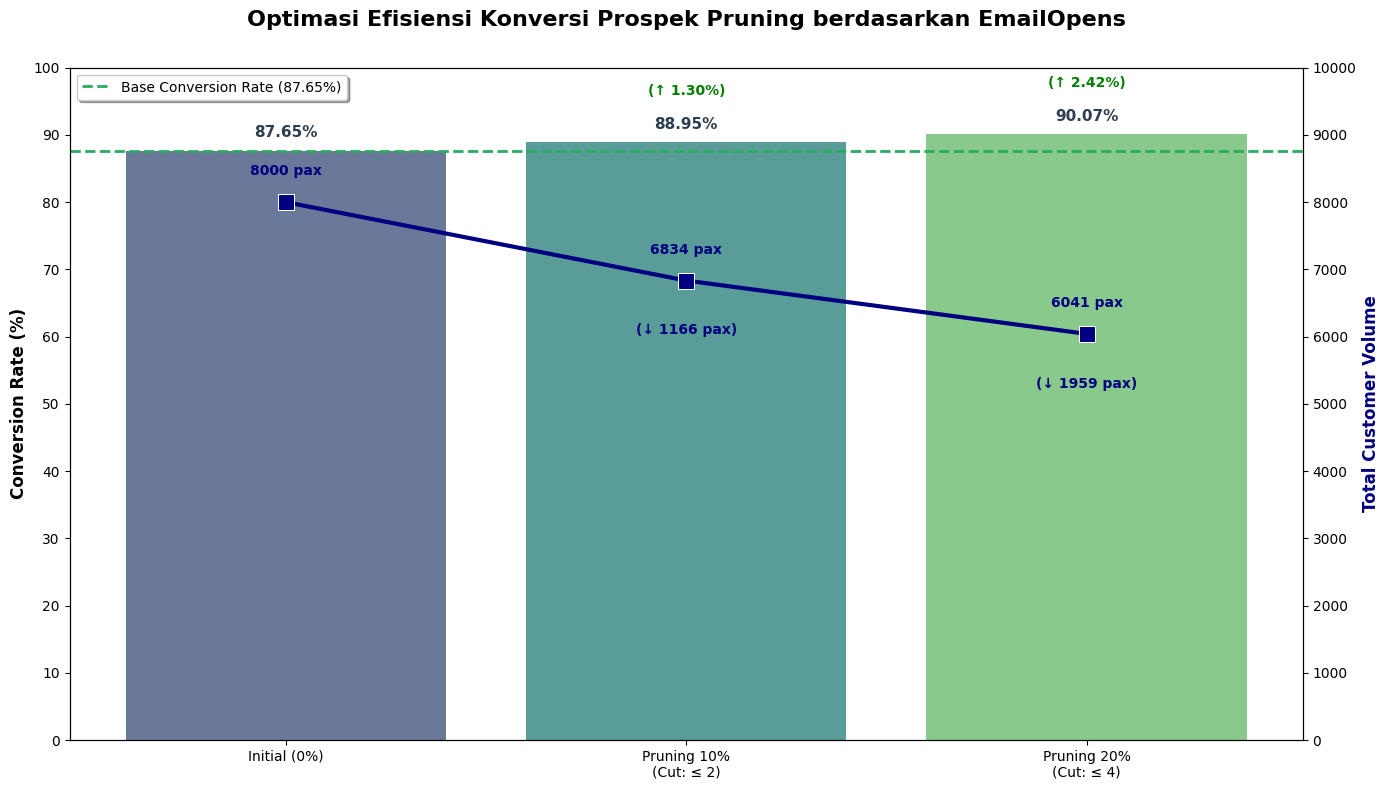

In [ ]:
# --- 1. PERHITUNGAN DATA (LOGIKA DYNAMIC PRUNING) ---
# Grouping untuk mencari segmen terburuk secara otomatis
df_email_stats = df_bins.groupby('EmailOpens_range')['Conversion'].mean().reset_index()

# Baseline (Initial)
cr_0 = df['Conversion'].mean() * 100
vol_0 = len(df)

# REMOVE 10% (Cari 1 Segmen Terburuk)
lowest_row_1 = df_email_stats.sort_values(by='Conversion').iloc[0]
lowest_segment = lowest_row_1['EmailOpens_range']
t10_val = df_bins[df_bins['EmailOpens_range'] == lowest_segment]['EmailOpens'].max()

df_10 = df_bins[df_bins['EmailOpens_range'] != lowest_segment]
cr_10 = df_10['Conversion'].mean() * 100
vol_10 = len(df_10)

# REMOVE 20% (Cari 2 Segmen Terburuk)
lowest_rows_2 = df_email_stats.sort_values(by='Conversion').head(2)
lowest_segments_2 = lowest_rows_2['EmailOpens_range'].tolist()
t20_val = df_bins[df_bins['EmailOpens_range'].isin(lowest_segments_2)]['EmailOpens'].max()

df_20 = df_bins[~df_bins['EmailOpens_range'].isin(lowest_segments_2)]
cr_20 = df_20['Conversion'].mean() * 100
vol_20 = len(df_20)

# Variabel untuk Visualisasi
scenarios = [
    'Initial (0%)',
    f'Pruning 10%\n(Cut: ≤ {round(t10_val, 2)})',
    f'Pruning 20%\n(Cut: ≤ {round(t20_val, 2)})'
]
rates = [cr_0, cr_10, cr_20]
volumes = [vol_0, vol_10, vol_20]

# Delta (Selisih)
diff_rate_10 = cr_10 - cr_0
diff_rate_20 = cr_20 - cr_0
diff_vol_10 = vol_0 - vol_10
diff_vol_20 = vol_0 - vol_20

# --- 2. VISUALISASI STRATEGIS ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# BAR CHART
sns.barplot(x=scenarios, y=rates, palette='viridis', ax=ax1, alpha=0.8)
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_yticks(np.arange(0, 101, 10))
ax1.grid(False)

# Annotasi Bar
for i, v in enumerate(rates):
    ax1.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', color='#2C3E50', fontsize=11)
    if i == 1:
        ax1.text(i, v + 7, f'(↑ {diff_rate_10:.2f}%)', ha='center', color='green', fontweight='bold')
    if i == 2:
        ax1.text(i, v + 7, f'(↑ {diff_rate_20:.2f}%)', ha='center', color='green', fontweight='bold')

# LINE CHART
ax2 = ax1.twinx()
sns.lineplot(x=scenarios, y=volumes, marker='s', markersize=12, color='#000080', linewidth=3, ax=ax2)
ax2.set_ylabel('Total Customer Volume', fontsize=12, fontweight='bold', color='#000080')
ax2.set_ylim(0, 10000)
ax2.set_yticks(np.arange(0, 10001, 1000))
ax2.grid(False)

# Annotasi Garis
for i, v in enumerate(volumes):
    ax2.text(i, v + 400, f'{int(v)} pax', ha='center', fontweight='bold', color='#000080')
    if i == 1:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_10)} pax)', ha='center', color='#000080', fontweight='bold')
    if i == 2:
        ax2.text(i, v - 800, f'(↓ {int(diff_vol_20)} pax)', ha='center', color='#000080', fontweight='bold')

# Target Line
ax1.axhline(87.65, color='#27AE60', linestyle='--', linewidth=2, label='Base Conversion Rate (87.65%)')

plt.title('Optimasi Efisiensi Konversi Prospek Pruning berdasarkan EmailOpens', fontsize=16, fontweight='bold', pad=30)
ax1.legend(loc='upper left', frameon=True, shadow=True)

# Memastikan bingkai tetap terlihat
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

#### Berdasarkan kolom `HistoryCR`

In [ ]:
# ========================
# GROUPING HISTORY_CR
# ========================
df_history_cr = df_bins.groupby('HistoryCR_range')['Conversion'].mean().reset_index()

# ========================
# BASELINE
# ========================
conversion_rate_total = df['Conversion'].mean()

print(f"Conversion Rate Awal : {conversion_rate_total * 100:.2f}%")

# ========================
# REMOVE 10% (1 SEGMENT TERBURUK)
# ========================
lowest_segment = df_history_cr.sort_values(by='Conversion').iloc[0]['HistoryCR_range']

df_history_cr_10 = df_bins[
    df_bins['HistoryCR_range'] != lowest_segment
]

conversion_rate_cr_10 = df_history_cr_10['Conversion'].mean()
diff_10 = (conversion_rate_cr_10 - conversion_rate_total) * 100

print(f"Conversion Rate setelah remove 10% bottom segment : {conversion_rate_cr_10 * 100:.2f}%")
print(f"Perubahan Conversion Rate : {diff_10:.2f}%")

# ========================
# REMOVE 20% (2 SEGMENT TERBURUK)
# ========================
lowest_segments_2 = df_history_cr.sort_values(by='Conversion').head(2)['HistoryCR_range']

df_history_cr_20 = df_bins[
    ~df_bins['HistoryCR_range'].isin(lowest_segments_2)
]

conversion_rate_cr_20 = df_history_cr_20['Conversion'].mean()
diff_20 = (conversion_rate_cr_20 - conversion_rate_total) * 100

print(f"Conversion Rate setelah remove 20% : {conversion_rate_cr_20 * 100:.2f}%")
print(f"Perubahan Conversion Rate : {diff_20:.2f}%")

Conversion Rate Awal : 87.65%
Conversion Rate setelah remove 10% bottom segment : 88.71%
Perubahan Conversion Rate : 1.06%
Conversion Rate setelah remove 20% : 89.94%
Perubahan Conversion Rate : 2.29%


/tmp/ipykernel_569/3836482072.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history_cr = df_bins.groupby('HistoryCR_range')['Conversion'].mean().reset_index()


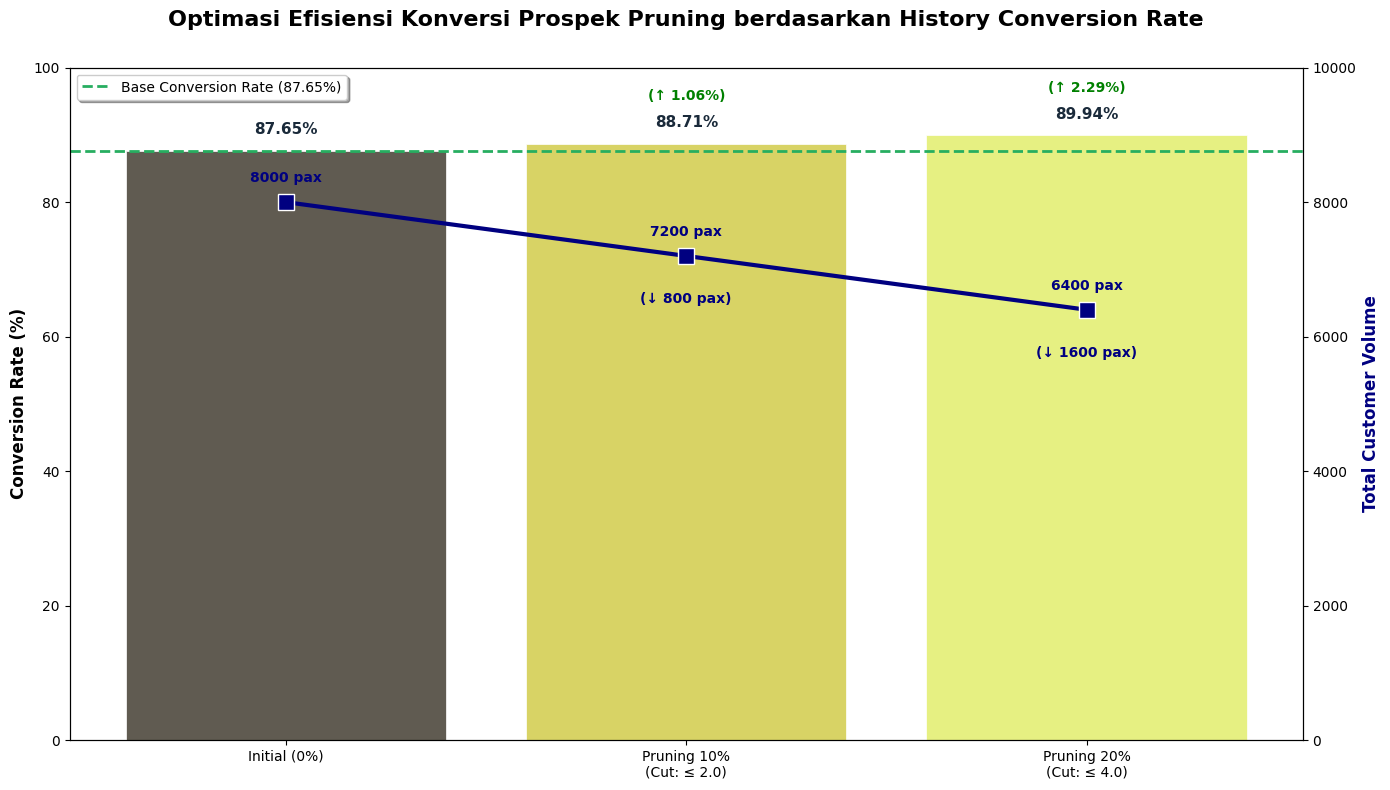

In [ ]:
# 1. Menyiapkan Data dan label sumbu x dan y
labels = ['Initial (0%)', 'Pruning 10%\n(Cut: ≤ 2.0)', 'Pruning 20%\n(Cut: ≤ 4.0)']
conv_rates = [conversion_rate_total * 100, conversion_rate_cr_10 * 100, conversion_rate_cr_20 * 100]
volumes = [len(df_bins), len(df_history_cr_10), len(df_history_cr_20)] # Mengetahui banyaknya customer
diff_pax = [volumes[0] - v for v in volumes]

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- BAR CHART (Conversion Rate) ---
colors = ['#605B51', '#D8D365', '#E6F082']
bars = ax1.bar(labels, conv_rates, color=colors, edgecolor='white', linewidth=0.5)

# Pengaturan Sumbu Y Kiri
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.axhline(y=conv_rates[0], color='#27ae60', linestyle='--', linewidth=2, label=f'Base Conversion Rate ({conv_rates[0]:.2f}%)')

# Label untuk Bar Chart
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold', color='#1a2a3a', fontsize=11)
    # Tambahkan teks kenaikan (hijau)
    if i > 0:
        diff = conv_rates[i] - conv_rates[0]
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 6, f"(↑ {diff:.2f}%)",
                 ha='center', va='bottom', color='green', fontweight='bold')

# --- LINE CHART (Customer Volume) ---
ax2 = ax1.twinx() # Membuat sumbu Y kedua
ax2.plot(labels, volumes, color='#000080', marker='s', markersize=12, linewidth=3, markerfacecolor='#000080', markeredgecolor='white')

# Pengaturan Sumbu Y Kanan
ax2.set_ylabel('Total Customer Volume', fontsize=12, fontweight='bold', color='#000080')
ax2.set_ylim(0, 10000)

# Anotasi angka pada Garis
for i, txt in enumerate(volumes):
    ax2.annotate(f"{txt} pax", (labels[i], volumes[i] + 300), color='#000080', fontweight='bold', ha='center')
    if i > 0:
        ax2.annotate(f"(↓ {diff_pax[i]} pax)", (labels[i], volumes[i] - 700), color='#000080', fontweight='bold', ha='center', fontsize=10)

# --- FINISHING ---
plt.title('Optimasi Efisiensi Konversi Prospek Pruning berdasarkan History Conversion Rate', fontsize=16, fontweight='bold', pad=30)
# Memanggil legend
ax1.legend(loc='upper left', shadow=True)

# Menghapus grid garis-garis di dalam agar bersih
ax1.grid(False)
ax2.grid(False)

# Memastikan bingkai tetap terlihat
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

#### Berdasarkan kolom Time On Site

In [ ]:
# ========================
# GROUPING TIME ON SITE
# ========================
df_time_site = df_bins.groupby('TimeOnSite_range')['Conversion'].mean().reset_index()

# ========================
# BASELINE
# ========================
conversion_rate_total = df['Conversion'].mean()

print(f"Conversion Rate Awal : {conversion_rate_total * 100:.2f}%")

# ========================
# REMOVE 10% (1 SEGMENT TERBURUK)
# ========================
lowest_segment = df_time_site.sort_values(by='Conversion').iloc[0]['TimeOnSite_range']

df_time_site_10 = df_bins[
    df_bins['TimeOnSite_range'] != lowest_segment
]

conversion_rate_tos_10 = df_time_site_10['Conversion'].mean()
diff_10 = (conversion_rate_tos_10 - conversion_rate_total) * 100

print(f"Conversion Rate setelah remove 10% bottom segment : {conversion_rate_tos_10 * 100:.2f}%")
print(f"Perubahan Conversion Rate : {diff_10:.2f}%")

# ========================
# REMOVE 20% (2 SEGMENT TERBURUK)
# ========================
lowest_segments_2 = df_time_site.sort_values(by='Conversion').head(2)['TimeOnSite_range']

df_time_site_20 = df_bins[
    ~df_bins['TimeOnSite_range'].isin(lowest_segments_2)
]

conversion_rate_tos_20 = df_time_site_20['Conversion'].mean()
diff_20 = (conversion_rate_tos_20 - conversion_rate_total) * 100

print(f"Conversion Rate setelah remove 20% : {conversion_rate_tos_20 * 100:.2f}%")
print(f"Perubahan Conversion Rate : {diff_20:.2f}%")

Conversion Rate Awal : 87.65%
Conversion Rate setelah remove 10% bottom segment : 88.60%
Perubahan Conversion Rate : 0.95%
Conversion Rate setelah remove 20% : 89.61%
Perubahan Conversion Rate : 1.96%


/tmp/ipykernel_569/2944219740.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_time_site = df_bins.groupby('TimeOnSite_range')['Conversion'].mean().reset_index()


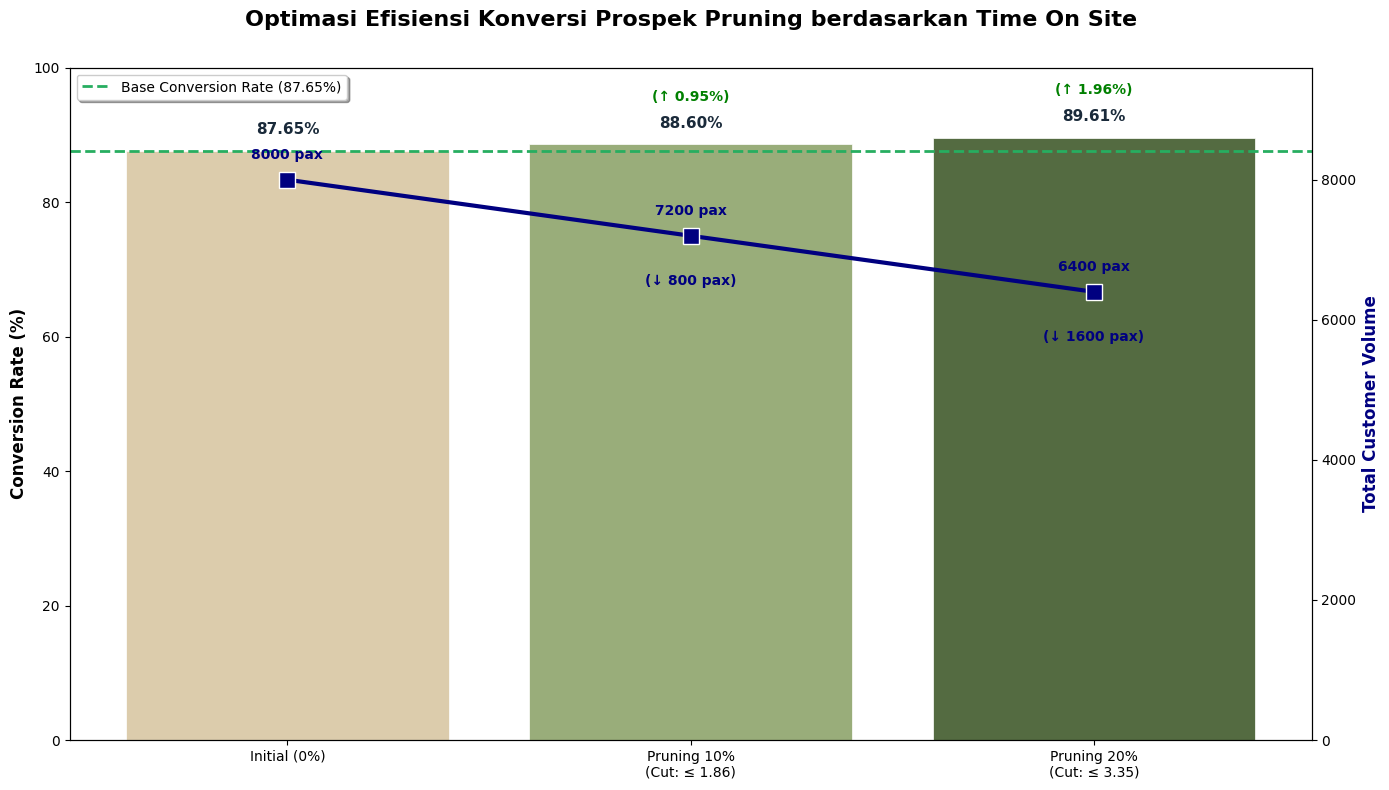

In [ ]:
# 1. Menyiapkan Data dan label sumbu x dan y
labels = ['Initial (0%)', 'Pruning 10%\n(Cut: ≤ 1.86)', 'Pruning 20%\n(Cut: ≤ 3.35)']
conv_rates = [conversion_rate_total * 100, conversion_rate_tos_10 * 100, conversion_rate_tos_20 * 100]
volumes = [len(df_bins), len(df_time_site_10), len(df_time_site_20)] # Mengetahui banyaknya customer
diff_pax = [volumes[0] - v for v in volumes]

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- BAR CHART (Conversion Rate) ---
colors = ['#DCCCAC', '#99AD7A', '#546B41']
bars = ax1.bar(labels, conv_rates, color=colors, edgecolor='white', linewidth=0.5)

# Pengaturan Sumbu Y Kiri
ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.axhline(y=conv_rates[0], color='#27ae60', linestyle='--', linewidth=2, label=f'Base Conversion Rate ({conv_rates[0]:.2f}%)')

# Label untuk Bar Chart
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold', color='#1a2a3a', fontsize=11)
    # Tambahkan teks kenaikan (hijau)
    if i > 0:
        diff = conv_rates[i] - conv_rates[0]
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 6, f"(↑ {diff:.2f}%)",
                 ha='center', va='bottom', color='green', fontweight='bold')

# --- LINE CHART (Customer Volume) ---
ax2 = ax1.twinx() # Membuat sumbu Y kedua
ax2.plot(labels, volumes, color='#000080', marker='s', markersize=12, linewidth=3, markerfacecolor='#000080', markeredgecolor='white')

# Pengaturan Sumbu Y Kanan
ax2.set_ylabel('Total Customer Volume', fontsize=12, fontweight='bold', color='#000080')
ax2.set_ylim(0, max(volumes) * 1.2)

# Anotasi angka pada Garis
for i, txt in enumerate(volumes):
    ax2.annotate(f"{txt} pax", (labels[i], volumes[i] + 300), color='#000080', fontweight='bold', ha='center')
    if i > 0:
        ax2.annotate(f"(↓ {diff_pax[i]} pax)", (labels[i], volumes[i] - 700), color='#000080', fontweight='bold', ha='center', fontsize=10)

# --- FINISHING ---
plt.title('Optimasi Efisiensi Konversi Prospek Pruning berdasarkan Time On Site', fontsize=16, fontweight='bold', pad=30)
# Memanggil legend
ax1.legend(loc='upper left', shadow=True)

# Menghapus grid
ax1.grid(False)
ax2.grid(False)

ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

#### =============== SUMMARY ===============

In [ ]:
# List untuk menampung semua hasil
summary_list = []
baseline_cr = 87.65
baseline_vol = 8000

# ======================================================
# 1. PREVIOUS PURCHASES
# ======================================================
df_pp_stats = df_bins.groupby('PreviousPurchases_range')['Conversion'].mean().reset_index()
df_sorted_pp = df_pp_stats.sort_values(by='Conversion')

# 10% Pruning
low_1_pp = df_sorted_pp.iloc[0]['PreviousPurchases_range']
df10_pp = df_bins[df_bins['PreviousPurchases_range'] != low_1_pp]
summary_list.append({'Feature': 'Previous Purchases', 'Strategy': 'Pruning 10%', 'Conversion Rate (%)': df10_pp['Conversion'].mean()*100, 'Volume': len(df10_pp)})

# 20% Pruning
low_2_pp = df_sorted_pp.head(2)['PreviousPurchases_range'].tolist()
df20_pp = df_bins[~df_bins['PreviousPurchases_range'].isin(low_2_pp)]
summary_list.append({'Feature': 'Previous Purchases', 'Strategy': 'Pruning 20%', 'Conversion Rate (%)': df20_pp['Conversion'].mean()*100, 'Volume': len(df20_pp)})


# ======================================================
# 2. PAGES PER VISIT
# ======================================================
df_ppv_stats = df_bins.groupby('PagesPerVisit_range')['Conversion'].mean().reset_index()
df_sorted_ppv = df_ppv_stats.sort_values(by='Conversion')

# 10% Pruning
low_1_ppv = df_sorted_ppv.iloc[0]['PagesPerVisit_range']
df10_ppv = df_bins[df_bins['PagesPerVisit_range'] != low_1_ppv]
summary_list.append({'Feature': 'Pages Per Visit', 'Strategy': 'Pruning 10%', 'Conversion Rate (%)': df10_ppv['Conversion'].mean()*100, 'Volume': len(df10_ppv)})

# 20% Pruning
low_2_ppv = df_sorted_ppv.head(2)['PagesPerVisit_range'].tolist()
df20_ppv = df_bins[~df_bins['PagesPerVisit_range'].isin(low_2_ppv)]
summary_list.append({'Feature': 'Pages Per Visit', 'Strategy': 'Pruning 20%', 'Conversion Rate (%)': df20_ppv['Conversion'].mean()*100, 'Volume': len(df20_ppv)})


# ======================================================
# 3. EMAIL OPENS
# ======================================================
df_email_stats = df_bins.groupby('EmailOpens_range')['Conversion'].mean().reset_index()
df_sorted_email = df_email_stats.sort_values(by='Conversion')

# 10% Pruning
low_1_em = df_sorted_email.iloc[0]['EmailOpens_range']
df10_em = df_bins[df_bins['EmailOpens_range'] != low_1_em]
summary_list.append({'Feature': 'Email Opens', 'Strategy': 'Pruning 10%', 'Conversion Rate (%)': df10_em['Conversion'].mean()*100, 'Volume': len(df10_em)})

# 20% Pruning
low_2_em = df_sorted_email.head(2)['EmailOpens_range'].tolist()
df20_em = df_bins[~df_bins['EmailOpens_range'].isin(low_2_em)]
summary_list.append({'Feature': 'Email Opens', 'Strategy': 'Pruning 20%', 'Conversion Rate (%)': df20_em['Conversion'].mean()*100, 'Volume': len(df20_em)})


# ======================================================
# 4. HISTORY CR (Column: HistoryCR_range)
# ======================================================
df_hcr_stats = df_bins.groupby('HistoryCR_range')['Conversion'].mean().reset_index()
df_sorted_hcr = df_hcr_stats.sort_values(by='Conversion')

# 10% Pruning
low_1_hcr = df_sorted_hcr.iloc[0]['HistoryCR_range']
df10_hcr = df_bins[df_bins['HistoryCR_range'] != low_1_hcr]
summary_list.append({'Feature': 'History CR', 'Strategy': 'Pruning 10%', 'Conversion Rate (%)': df10_hcr['Conversion'].mean()*100, 'Volume': len(df10_hcr)})

# 20% Pruning
low_2_hcr = df_sorted_hcr.head(2)['HistoryCR_range'].tolist()
df20_hcr = df_bins[~df_bins['HistoryCR_range'].isin(low_2_hcr)]
summary_list.append({'Feature': 'History CR', 'Strategy': 'Pruning 20%', 'Conversion Rate (%)': df20_hcr['Conversion'].mean()*100, 'Volume': len(df20_hcr)})


# ======================================================
# 5. TIME ON SITE
# ======================================================
df_tos_stats = df_bins.groupby('TimeOnSite_range')['Conversion'].mean().reset_index()
df_sorted_tos = df_tos_stats.sort_values(by='Conversion')

# 10% Pruning
low_1_tos = df_sorted_tos.iloc[0]['TimeOnSite_range']
df10_tos = df_bins[df_bins['TimeOnSite_range'] != low_1_tos]
summary_list.append({'Feature': 'Time On Site', 'Strategy': 'Pruning 10%', 'Conversion Rate (%)': df10_tos['Conversion'].mean()*100, 'Volume': len(df10_tos)})

# 20% Pruning
low_2_tos = df_sorted_tos.head(2)['TimeOnSite_range'].tolist()
df20_tos = df_bins[~df_bins['TimeOnSite_range'].isin(low_2_tos)]
summary_list.append({'Feature': 'Time On Site', 'Strategy': 'Pruning 20%', 'Conversion Rate (%)': df20_tos['Conversion'].mean()*100, 'Volume': len(df20_tos)})


# ======================================================
# FINAL SUMMARY DATAFRAME
# ======================================================
df_summary = pd.DataFrame(summary_list)
df_summary['CR Improvement (%)'] = df_summary['Conversion Rate (%)'] - baseline_cr
df_summary['Volume Loss (pax)'] = baseline_vol - df_summary['Volume']

# Tampilkan Hasil
print("==== FINAL SUMMARY OPTIMASI PRUNING ====")
display(df_summary.sort_values(by='Conversion Rate (%)', ascending=False).reset_index(drop=True))

==== FINAL SUMMARY OPTIMASI PRUNING ====


/tmp/ipykernel_569/894365511.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pp_stats = df_bins.groupby('PreviousPurchases_range')['Conversion'].mean().reset_index()
/tmp/ipykernel_569/894365511.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ppv_stats = df_bins.groupby('PagesPerVisit_range')['Conversion'].mean().reset_index()
/tmp/ipykernel_569/894365511.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Feature,Strategy,Conversion Rate (%),Volume,CR Improvement (%),Volume Loss (pax)
0,Previous Purchases,Pruning 20%,90.737070,5549,3.087070,2451
1,Pages Per Visit,Pruning 20%,90.550150,5344,2.900150,2656
2,Previous Purchases,Pruning 10%,90.530779,6368,2.880779,1632
3,Pages Per Visit,Pruning 10%,90.387993,6263,2.737993,1737
4,Email Opens,Pruning 20%,90.067870,6041,2.417870,1959
5,History CR,Pruning 20%,89.937500,6400,2.287500,1600
6,Time On Site,Pruning 20%,89.609375,6400,1.959375,1600
7,Email Opens,Pruning 10%,88.952297,6834,1.302297,1166
8,History CR,Pruning 10%,88.708333,7200,1.058333,800
9,Time On Site,Pruning 10%,88.597222,7200,0.947222,800


**Insight**
- Variabel **Previous Purchase** dan **Pages per Visit** secara konsisten memberikan dampak kenaikan CR tertinggi pada kedua skenario (Pruning 10% maupun 20%). Ini menunjukkan bahwa riwayat transaksi dan kedalaman eksplorasi situs adalah indikator paling valid untuk menyaring pelanggan berkualitas tinggi.
- Variabel Time On Site dan History CR memberikan CR Improvement yang paling rendah (di bawah 2% untuk pruning 20%, dan bahkan di bawah 1% untuk pruning 10%). Hal ini menandakan bahwa kedua metrik ini kurang sensitif dalam memisahkan pelanggan produktif dan tidak produktif dibandingkan metrik aktivitas langsung.
- Penerapan strategi ini memerlukan evaluasi mendalam terhadap korelasi antara pengurangan jumlah pelanggan dan peningkatan Conversion Rate (CR). Perlu dipastikan apakah pertumbuhan nilai CR cukup signifikan untuk mngorbankan kehilangan volume pelanggan (volume loss), sehingga efisiensi yang dicapai sebanding dengan skala pasar yang dikorbankan

**Rekomendasi**

Berdasarkan hasil analisis, penerapan metode pruning yang paling efektif dengan meninjau kenaikan conversion rate dan kehilangan jumlah pelanggan, yaitu dengan **melakukan pruning 10% pada Previous Purchases**. Pada simulasi ini, **kita mendapatkan kenaikan konversi yang cukup signifikan (+2.88%) dengan haanya kehilangan 1632 pelanggan**. Sedangkan untuk Pruning 20% kita hanya mendapat kenaikan 3.08% (hanya beda 0.2%), tetapi dengan jumlah pelanggan yang dibuang melonjak drastis sebesar 2451 pelanggan.

###  Bagaimana metode Customer Purning dapat mengoptimalkan alokasi anngaran iklan (AdSpend) ?

In [ ]:
# --- 1. DEFINISI FUNGSI IMPACT ---
def calculate_impact(df_original, df_pruned, feature_name, strategy_label):
    # Saving: Total AdSpend yang dihemat dengan mengeluarkan segmen berkinerja rendah
    total_saving = df_original['AdSpend'].sum() - df_pruned['AdSpend'].sum()

    # Loss: Jumlah customer yang melakukan conversion yang terhapus selama proses pruning
    total_loss_conv = df_original['Conversion'].sum() - df_pruned['Conversion'].sum()

    # Efficiency: AdSpend yang dihemat untuk setiap satu konversi yang dikorbankan
    saving_per_lost_conv = total_saving / total_loss_conv if total_loss_conv > 0 else total_saving

    return {
        'Feature': feature_name,
        'Strategy': strategy_label,
        'Conversion Rate (%)': round(df_pruned['Conversion'].mean() * 100, 2),
        'Total Savings (AdSpend Saved)': round(total_saving, 2),
        'Total Loss (Conv Dropped)': int(total_loss_conv),
        'Savings per Lost Conv': round(saving_per_lost_conv, 2)
    }

# --- 2. LOOPING PERHITUNGAN UNTUK 5 KOLOM ---
impact_results = []
feature_map = {
    'Previous Purchases': 'PreviousPurchases_range',
    'Pages Per Visit': 'PagesPerVisit_range',
    'Email Opens': 'EmailOpens_range',
    'History CR': 'HistoryCR_range',
    'Time On Site': 'TimeOnSite_range'
}

for label, col_range in feature_map.items():
    # Grouping untuk cari segmen terburuk
    df_stats = df_bins.groupby(col_range)['Conversion'].mean().reset_index()
    df_sorted = df_stats.sort_values(by='Conversion')

    # --- PRUNING 10% (1 Segmen Terburuk) ---
    low_1 = df_sorted.iloc[0][col_range]
    df_pruned_10 = df_bins[df_bins[col_range] != low_1]
    impact_results.append(calculate_impact(df_bins, df_pruned_10, label, 'Pruning 10%'))

    # --- PRUNING 20% (2 Segmen Terburuk) ---
    low_2 = df_sorted.head(2)[col_range].tolist()
    df_pruned_20 = df_bins[~df_bins[col_range].isin(low_2)]
    impact_results.append(calculate_impact(df_bins, df_pruned_20, label, 'Pruning 20%'))

# --- 3. TAMPILKAN SUMMARY FINANSIAL ---
df_final_impact = pd.DataFrame(impact_results)

print("==== FINAL FINANCIAL & CONVERSION IMPACT SUMMARY ====")
# Sort berdasarkan Savings per Lost Conv paling tinggi
display(df_final_impact.sort_values(by='Savings per Lost Conv', ascending=False).reset_index(drop=True))

==== FINAL FINANCIAL & CONVERSION IMPACT SUMMARY ====


/tmp/ipykernel_569/885084004.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_range)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/885084004.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_range)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/885084004.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_r

,Feature,Strategy,Conversion Rate (%),Total Savings (AdSpend Saved),Total Loss (Conv Dropped),Savings per Lost Conv
0,Previous Purchases,Pruning 10%,90.53,8177164.37,1247,6557.47
1,Pages Per Visit,Pruning 10%,90.39,8772659.76,1351,6493.46
2,History CR,Pruning 10%,88.71,4031142.08,625,6449.83
3,History CR,Pruning 20%,89.94,8054685.01,1256,6412.97
4,Time On Site,Pruning 20%,89.61,7996509.23,1277,6261.95
5,Email Opens,Pruning 10%,88.95,5822469.88,933,6240.59
6,Email Opens,Pruning 20%,90.07,9755391.26,1571,6209.67
7,Previous Purchases,Pruning 20%,90.74,12199391.97,1977,6170.66
8,Time On Site,Pruning 10%,88.60,3874757.86,633,6121.26
9,Pages Per Visit,Pruning 20%,90.55,13299319.50,2173,6120.26


**Insight**:

*   **Skenario Previous Purchases (Pruning 10%) merupakan titik optimal (sweet spot) bagi efisiensi anggaran**. Strategi ini menghasilkan nilai penghematan tertinggi per satu konversi yang hilang ($6,557)
*   **Previous Purchases dan HistoryCR memiliki korelasi kuat terhadap nilai konversi**. Pruning sebesar 20% pada sektor ini tetap menjaga Conversion Rate di atas 90%
*   Pruning pada Email Opens (20%) menyelamatkan hampir 9.7 Juta AdSpend dengan mempertahankan Conversion Rate tetap tinggi (90.07%). Banyak user yang membuka email ternyata tidak benar-benar berniat membeli. Mengurangi intensitas iklan pada segmen ini memberikan ruang budget yang besar untuk dialokasikan ke kanal akuisisi baru
*   Strategi Pages Per Visit (Pruning 20%) memang memberikan total saving terbesar secara nominal (13.2 Juta), namun dengan risiko kehilangan konversi terbanyak (2,173 conv)




**Rekomendasi:**

Berdasarkan hasil analisis dampak finansial dari berbagai skenario pruning, strategi yang paling direkomendasikan adalah **Pruning 10% pada variabel Previous Purchases**. Skenario ini menghasilkan nilai **Savings per Lost Conv** tertinggi sebesar **6,557.47**. Artinya, untuk setiap satu potensi pembeli yang hilang akibat pruning, perusahaan berhasil menghemat biaya iklan dalam jumlah yang sangat signifikan.** Dengan hanya mengorbankan 1.247 potensi konversi, perusahaan dapat menghemat anggaran AdSpend sebesar $8,17M**. Dana ini dapat dialokasikan kembali ke kanal akuisisi lain yang memiliki tingkat konversi lebih tinggi




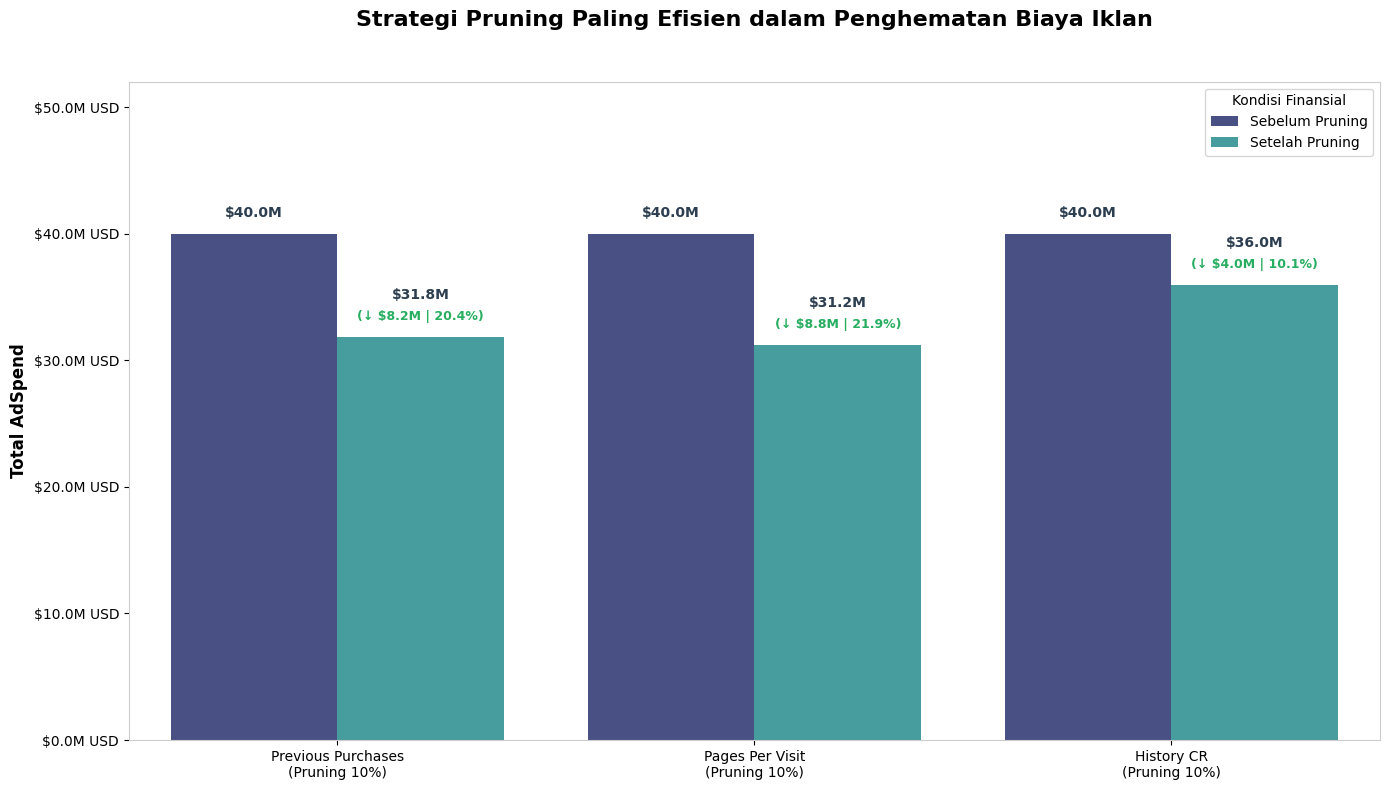

In [ ]:
# --- 1. PREPARASI DATA ---
df_top3 = df_final_impact.sort_values(by='Savings per Lost Conv', ascending=False).head(3).copy()
total_adspend_initial = df_bins['AdSpend'].sum()
df_top3['AdSpend_Before'] = total_adspend_initial
df_top3['AdSpend_After'] = total_adspend_initial - df_top3['Total Savings (AdSpend Saved)']
df_top3['Saving_Pct'] = (df_top3['Total Savings (AdSpend Saved)'] / total_adspend_initial) * 100
df_top3['Saving_Amount'] = df_top3['Total Savings (AdSpend Saved)']

df_top3['Scenario_Label'] = df_top3['Feature'] + "\n(" + df_top3['Strategy'] + ")"

df_plot = df_top3.melt(id_vars=['Scenario_Label', 'Saving_Pct', 'Saving_Amount'],
                       value_vars=['AdSpend_Before', 'AdSpend_After'],
                       var_name='Condition',
                       value_name='AdSpend_Amount')

df_plot['Condition'] = df_plot['Condition'].replace({
    'AdSpend_Before': 'Sebelum Pruning',
    'AdSpend_After': 'Setelah Pruning'
})

def format_m_usd(x, pos):
    return f'${x/1e6:.1f}M USD'

# --- 2. VISUALISASI ---
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=df_plot, x='Scenario_Label', y='AdSpend_Amount', hue='Condition', palette='mako')
ax.yaxis.set_major_formatter(FuncFormatter(format_m_usd))

# --- 3. STYLE ---
plt.title('Strategi Pruning Paling Efisien dalam Penghematan Biaya Iklan', fontsize=16, fontweight='bold', pad=40)
plt.ylabel('Total AdSpend', fontsize=12, fontweight='bold')
plt.xlabel('', fontsize=12)
plt.ylim(0, total_adspend_initial * 1.3)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#CCCCCC')
ax.grid(False)

# --- 4. LABEL ANGKA DINAMIS ---
# Ambil dictionary untuk mapping data saving berdasarkan label bar
savings_val_dict = dict(zip(df_top3['Scenario_Label'], df_top3['Saving_Amount']))
savings_pct_dict = dict(zip(df_top3['Scenario_Label'], df_top3['Saving_Pct']))

for p in ax.patches:
    height = p.get_height()
    if height <= 0: continue

    # Ambil label x-axis
    idx = int(p.get_x() + p.get_width()/2)
    x_label = ax.get_xticklabels()[idx].get_text()

    # Nilai budget sisa/awal
    display_val = f'${height/1e6:.1f}M'

    if height < total_adspend_initial:
        # BAR SETELAH PRUNING
        ax.annotate(display_val,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 25),
                    textcoords='offset points', fontsize=10, fontweight='bold', color='#2C3E50')

        # Rincian penghematan di bawahnya
        saved_amt = savings_val_dict[x_label]
        pct = savings_pct_dict[x_label]
        ax.annotate(f'(↓ ${saved_amt/1e6:.1f}M | {pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 10),
                    textcoords='offset points', fontsize=9, fontweight='bold', color='#27AE60')
    else:
        # BAR SEBELUM PRUNING
        ax.annotate(display_val,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold', color='#2C3E50')

plt.legend(title='Kondisi Finansial', frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

**Insight:**


*   **Strategi Previous Purchases (Pruning 10%) merupakan rekomendasi utama karena memiliki tingkat presisi tertinggi**. Meskipun secara nominal penghematannya (20.4%) sedikit di bawah Pages Per Visit, strategi ini jauh lebih efisien dalam menjaga basis pelanggan aktif
*   **Strategi Pages Per Visit (Pruning 10%) memberikan total penghematan anggaran terbesar secara nominal (↓ $8.8M atau 21.9%)**. Hal ini dikarenakan variabel tersebut mampu memfilter volume trafik "low-intent" dalam jumlah yang lebih masif
*   Pemangkasan budget sebesar ~20% pada segmen tidak produktif ini memungkinkan perusahaan untuk memiliki **sisa budget iklan sebesar 31.2M - 31.8M** yang jauh lebih sehat dan memiliki ROI lebih tinggi

**Rekomendasi:**
**Perusahaan direkomendasikan untuk menerapkan Previous Purchases (Pruning 10%) sebagai strategi utama optimasi anggaran**. Meskipun strategi Pages Per Visit menawarkan nominal penghematan total yang lebih besar, Previous Purchases unggul dalam presisi pemangkasan biaya dengan risiko kehilangan pelanggan aktif yang paling rendah. Fokus pada efisiensi ini memastikan pengurangan AdSpend dilakukan secara strategis pada segmen dengan ROI terendah, sehingga profitabilitas meningkat tanpa mengorbankan stabilitas pangsa pasar secara agresif





## Kesimpulan

In [ ]:
# List untuk menampung semua hasil gabungan
combined_summary = []
baseline_cr = 87.65
baseline_vol = 8000
total_adspend_initial = df_bins['AdSpend'].sum()
avg_adspend_per_pax = total_adspend_initial / baseline_vol

# Daftar fitur yang akan diproses secara otomatis
features = {
    'Previous Purchases': 'PreviousPurchases_range',
    'Pages Per Visit': 'PagesPerVisit_range',
    'Email Opens': 'EmailOpens_range',
    'History CR': 'HistoryCR_range',
    'Time On Site': 'TimeOnSite_range'
}

for feature_name, col_name in features.items():
    # Hitung statistik per grup
    df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
    df_sorted = df_stats.sort_values(by='Conversion')

    # Pruning 10% (1 Segmen Terburuk) & 20% (2 Segmen Terburuk)
    for ratio in [10, 20]:
        num_segments = 1 if ratio == 10 else 2
        low_segments = df_sorted.head(num_segments)[col_name].tolist()

        # Filter data setelah pruning
        df_pruned = df_bins[~df_bins[col_name].isin(low_segments)]

        # --- PERHITUNGAN METRIK ---
        current_vol = len(df_pruned)
        lost_vol = baseline_vol - current_vol
        current_cr = df_pruned['Conversion'].mean() * 100

        # Hitung Savings (AdSpend yang tidak jadi dikeluarkan untuk user yang di-prune)
        total_savings = lost_vol * avg_adspend_per_pax

        # Hitung Lost Conversions (Berapa banyak pembeli yang hilang akibat pruning)
        # (Volume yang di-prune * CR segmen yang di-prune)
        df_lost = df_bins[df_bins[col_name].isin(low_segments)]
        lost_conv = df_lost['Conversion'].sum()

        # Metrik Efisiensi: Savings per Lost Conv
        # Jika lost_conv 0 (tidak ada pembeli yang hilang), set ke total_savings
        savings_per_lost_conv = total_savings / lost_conv if lost_conv > 0 else total_savings

        combined_summary.append({
            'Feature': feature_name,
            'Strategy': f'Pruning {ratio}%',
            'Conversion Rate (%)': current_cr,
            'Savings per Lost Conv': savings_per_lost_conv
        })

# --- FINAL SUMMARY ---
df_final_summary = pd.DataFrame(combined_summary)

# Tampilkan kolom yang diminta saja, diurutkan berdasarkan CR tertinggi
print("==== SUMMARY OPTIMASI: CONVERSION VS EFFICIENCY ====")
display(df_final_summary[['Feature', 'Strategy', 'Conversion Rate (%)', 'Savings per Lost Conv']]
        .sort_values(by='Conversion Rate (%)', ascending=False)
        .reset_index(drop=True))

==== SUMMARY OPTIMASI: CONVERSION VS EFFICIENCY ====


/tmp/ipykernel_569/2750572911.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/2750572911.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/2750572911.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_

,Feature,Strategy,Conversion Rate (%),Savings per Lost Conv
0,Previous Purchases,Pruning 20%,90.737070,6199.957400
1,Pages Per Visit,Pruning 20%,90.550150,6112.521615
2,Previous Purchases,Pruning 10%,90.530779,6544.941430
3,Pages Per Visit,Pruning 10%,90.387993,6429.786211
4,Email Opens,Pruning 20%,90.067870,6236.060422
5,History CR,Pruning 20%,89.937500,6370.630357
6,Time On Site,Pruning 20%,89.609375,6265.866663
7,Email Opens,Pruning 10%,88.952297,6249.841021
8,History CR,Pruning 10%,88.708333,6401.209383
9,Time On Site,Pruning 10%,88.597222,6320.309422


In [ ]:
# List untuk menampung semua hasil gabungan
combined_summary = []
total_adspend_initial = df_bins['AdSpend'].sum()
total_conv_initial = df_bins['Conversion'].sum()

# Daftar fitur yang diproses
features = {
    'Previous Purchases': 'PreviousPurchases_range',
    'Pages Per Visit': 'PagesPerVisit_range',
    'Email Opens': 'EmailOpens_range',
    'History CR': 'HistoryCR_range',
    'Time On Site': 'TimeOnSite_range'
}

for feature_name, col_name in features.items():
    # Hitung statistik per grup untuk mencari segmen terburuk
    df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
    df_sorted = df_stats.sort_values(by='Conversion')

    # Loop untuk Pruning 10% dan 20%
    for ratio in [10, 20]:
        num_segments = 1 if ratio == 10 else 2
        low_segments = df_sorted.head(num_segments)[col_name].tolist()

        # Data yang tersisa setelah pruning
        df_pruned = df_bins[~df_bins[col_name].isin(low_segments)]

        # --- PERHITUNGAN ---
        # Selisih AdSpend
        total_savings = total_adspend_initial - df_pruned['AdSpend'].sum()
        # Selisih Conversion
        lost_conv = total_conv_initial - df_pruned['Conversion'].sum()
        # CR data tersisa
        current_cr = df_pruned['Conversion'].mean() * 100
        # Rasio Efisiensi
        savings_per_lost_conv = total_savings / lost_conv if lost_conv > 0 else total_savings

        combined_summary.append({
            'Feature': feature_name,
            'Strategy': f'Pruning {ratio}%',
            'Conversion Rate (%)': round(current_cr, 2),
            'Savings per Lost Conv': round(savings_per_lost_conv, 2)
        })

# Tampilkan Summary
df_final_summary = pd.DataFrame(combined_summary)
print("==== SUMMARY OPTIMASI: CONVERSION VS EFFICIENCY (REAL ADSPEND) ====")
display(df_final_summary[['Feature', 'Strategy', 'Conversion Rate (%)', 'Savings per Lost Conv']]
        .sort_values(by='Conversion Rate (%)', ascending=False)
        .reset_index(drop=True))

==== SUMMARY OPTIMASI: CONVERSION VS EFFICIENCY (REAL ADSPEND) ====


/tmp/ipykernel_569/3243844389.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/3243844389.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_name)['Conversion'].mean().reset_index()
/tmp/ipykernel_569/3243844389.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = df_bins.groupby(col_

,Feature,Strategy,Conversion Rate (%),Savings per Lost Conv
0,Previous Purchases,Pruning 20%,90.74,6170.66
1,Pages Per Visit,Pruning 20%,90.55,6120.26
2,Previous Purchases,Pruning 10%,90.53,6557.47
3,Pages Per Visit,Pruning 10%,90.39,6493.46
4,Email Opens,Pruning 20%,90.07,6209.67
5,History CR,Pruning 20%,89.94,6412.97
6,Time On Site,Pruning 20%,89.61,6261.95
7,Email Opens,Pruning 10%,88.95,6240.59
8,History CR,Pruning 10%,88.71,6449.83
9,Time On Site,Pruning 10%,88.60,6121.26


/tmp/ipykernel_569/3478016261.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top5, x='Scenario', y='Conversion Rate (%)', ax=ax1, palette='viridis', alpha=0.7)


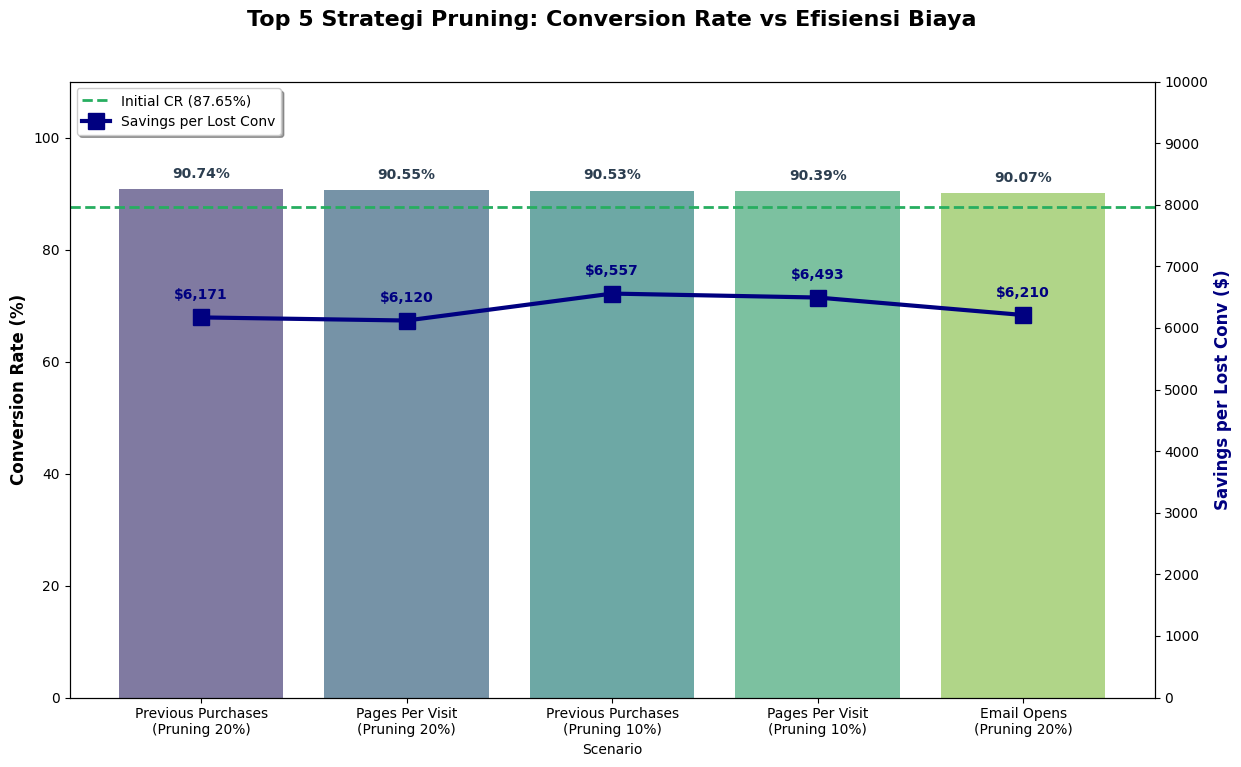

In [ ]:
# --- 1. PREPARASI DATA TOP 5 ---
df_top5 = df_final_summary.sort_values(by='Conversion Rate (%)', ascending=False).head(5).copy()
df_top5['Scenario'] = df_top5['Feature'] + "\n(" + df_top5['Strategy'] + ")"

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- 2. BAR CHART (Conversion Rate) ---
sns.barplot(data=df_top5, x='Scenario', y='Conversion Rate (%)', ax=ax1, palette='viridis', alpha=0.7)

ax1.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 110)
# Update skala: per 20
ax1.set_yticks(np.arange(0, 111, 20))
ax1.grid(False)

# Annotasi Bar
for i, v in enumerate(df_top5['Conversion Rate (%)']):
    ax1.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', color='#2C3E50')

# --- 3. LINE CHART (Savings per Lost Conv) ---
ax2 = ax1.twinx()
lns2 = ax2.plot(df_top5['Scenario'], df_top5['Savings per Lost Conv'],
                marker='s', markersize=12, color='#000080', linewidth=3,
                label='Savings per Lost Conv')

ax2.set_ylabel('Savings per Lost Conv ($)', fontsize=12, fontweight='bold', color='#000080')
# Skala tetap 0 - 10000 dengan interval 1000
ax2.set_ylim(0, 10000)
ax2.set_yticks(np.arange(0, 10001, 1000))
ax2.grid(False)

# Annotasi Garis (Navy)
for i, v in enumerate(df_top5['Savings per Lost Conv']):
    ax2.text(i, v + 300, f'${v:,.0f}', ha='center', fontweight='bold', color='#000080')

# --- 4. FINISHING (BINGKAI & LEGEND TUNGGAL) ---
plt.title('Top 5 Strategi Pruning: Conversion Rate vs Efisiensi Biaya',
          fontsize=16, fontweight='bold', pad=40)

# Base CR Line
lns1 = ax1.axhline(87.65, color='#27AE60', linestyle='--', linewidth=2, label='Initial CR (87.65%)')

# Gabungkan label ke satu legend
all_lns = [lns1] + lns2
all_labs = [l.get_label() for l in all_lns]
ax1.legend(all_lns, all_labs, loc='upper left', frameon=True, shadow=True)

# Bingkai Solid Tertutup
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)

**Insight:**


*   Seluruh Top 5 skenario berhasil mempertahankan Conversion Rate (CR) di atas baseline 87.65%. Hal ini membuktikan bahwa metode pruning efektif dalam mengeliminasi segmen "sampah" tanpa merusak performa penjualan
* Skenario Previous Purchases (Pruning 10%) merupakan titik efisiensi biaya tertinggi (puncak garis biru). Strategi ini memberikan kompensasi penghematan sebesar $6,545 per satu konversi yang hilang, menjadikannya pilihan paling cerdas untuk menjaga profitabilitas


*   Skenario Previous Purchases (Pruning 20%) mencatatkan CR tertinggi (90.74%). Meskipun efisiensi biayanya sedikit di bawah skenario 10%, strategi ini menunjukkan bahwa semakin ketat kita menyaring pelanggan berdasarkan riwayat pembelian, semakin tinggi kualitas trafik yang tersisa

*   Terdapat tren di mana skenario dengan Saving per Lost Conv yang sangat tinggi cenderung memiliki CR yang sedikit lebih rendah dibanding skenario pruning agresif (20%), namun perbedaannya sangat tipis (hanya selisih ~0.2-0.5%)



## Rekomendasi

1. Selective Pruning : Fokus pada pruning 10% di Previous Purchase untuk mengeliminasi segmen low-value tanpa mengorbankan banyak konversi
2. Maximize Efficiency : Optimalkan alokasi budget ke segmen dengan cost-efficiency tertinggi (Savings per Lost Conv tinggi = $6,557)
3. Audience Prioritization : Prioritaskan audiens dengan high intent (Previous Purchase 3–4 & Email Opens 8–9) yang terbukti punya CR >92%
4. Reallocate Budget : Alihkan budget yang dihemat (~20%) ke channel atau segmen dengan performa conversion terbaik
5. Track & Optimize : Lakukan monitoring berkala terhadap CR, CPA, dan engagement untuk memastikan strategi tetap optimal.


In [ ]:
# Menghitung CPA rata-rata sebelum pruning (Baseline)
# Hitung total AdSpend awal (Baseline)
total_adspend_awal = df['AdSpend'].sum()

# Hitung total Konversi awal (Baseline)
# Ganti 'Converted' dengan nama kolom target/label konversimu
total_konversi_awal = df['Conversion'].sum()

# Hitung CPA Normal (Rata-rata)
cpa_normal = total_adspend_awal / total_konversi_awal

print(f"Total AdSpend: ${total_adspend_awal:,.2f}")
print(f"Total Konversi: {total_konversi_awal}")
print(f"CPA Normal: ${cpa_normal:,.2f}")

Total AdSpend: $40,007,558.64
Total Konversi: 7012
CPA Normal: $5,705.58
